# GENIE CCQE systematic covariances (notebook)

Interactive / notebook production of **rate** and **xsec** covariances for the
**CCQE** GENIE knob group (Aug24 ``sel_mup`` stamp
``2026_08_24_125255__sel_mup-wgts_genie_CCQE``).

**Configured below for:**
- Input: ``GENIE_GROUP_GLOBS["CCQE"]``
- Variables: ``integrated``, ``tki-del_Tp``, ``tki-del_alpha``, ``tki-del_phi``
- Knobs: ``GENIE_GROUP_KNOBS["CCQE"]`` (2 multisim knobs × 100 universes)
- Per-knob ``n_univ`` after normalize (ready for mixed groups)
- No Ar23p-style family collapsing — breakdown is per-knob only

Writes under ``systematics-notebook-CCQE-*/GENIE/`` via ``syst_disk_layout``.


Configuration cells set the CCQE input glob, analysis variables, and CCQE knob list.
Run those first, then the load / FV / TKI / covariance cells below.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from datetime import datetime
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
from pandas.errors import PerformanceWarning
from tqdm import tqdm

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')

from pyanalib.split_df_helpers import *
from pyanalib.covariance import get_covariance_matrix
from pyanalib.variable_calculator import get_cc1p0pi_tki
from pyanalib.pandas_helpers import pad_column_name

from analysis_village.numucc_1p0pi.variable_configs import VariableConfig, var_configs_measurement
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.categories import get_topo_category
from analysis_village.numucc_1p0pi.selection_framework import multicol_resolve_column_key
from analysis_village.numucc_1p0pi.dataset_locations import (
    GENIE_GROUP_GLOBS,
    GENIE_GROUP_GLOBS_SEL_ALL,
    GENIE_GROUP_KNOBS,
    MULTISIM_SYST_GLOBS_FINAL,
)
from analysis_village.numucc_1p0pi.scripts.get_systematics_genie import (
    normalize_and_infer_n_univ,
)
from analysis_village.numucc_1p0pi.syst_multisim_common import (
    NEUTRINO_SYST_ORDER,
    drop_bad_flux_knob_weights,
    drop_bad_g4_knob_weights,
    drop_bad_genie_weights,
    flux_mc_knob_names,
    g4_mc_knob_names,
    parse_neutrino_syst_type_csv,
    save_neutrino_multisim_npzs,
    syst_key_for_name,
)
from analysis_village.numucc_1p0pi.syst_disk_layout import category_out_dir, normalized_root

warnings.filterwarnings('ignore', category=PerformanceWarning)
plt.style.use('presentation.mplstyle')


def _ts():
    return datetime.now().strftime('%H:%M:%S')


def _log(msg):
    print(f'[{_ts()}] {msg}', flush=True)


In [3]:
# Analysis variables: integrated + 3 TKI (same set as sel_mup Aug24 GENIE runs)
var_configs = [
    VariableConfig.all_events(),       # var_save_name = "integrated"
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
]
_log("var_configs: " + ", ".join(vc.var_save_name for vc in var_configs))


[02:24:55] var_configs: integrated, tki-del_Tp, tki-del_alpha, tki-del_phi


In [4]:
# --- CCQE GENIE run configuration ---
# Category label used for syst_disk output (GENIE/). Data come from GENIE_GROUP below.
SYST_TYPES = ["GENIE"]

# Knob group / input stamp (see dataset_locations.GENIE_GROUP_GLOBS*)
GENIE_GROUP = "CCQE"
# "final" → Aug24 sel_mup (evt+mcnu, already selected); "sel_all" → sel_all CCQE stamp
MC_DF_STAGE = os.environ.get("MC_DF_STAGE", "final")

if MC_DF_STAGE == "sel_all":
    _genie_glob = GENIE_GROUP_GLOBS_SEL_ALL[GENIE_GROUP]
    FILENAME_STR = "sel_all"
else:
    _genie_glob = GENIE_GROUP_GLOBS[GENIE_GROUP]
    FILENAME_STR = "sel_mup"

GENIE_INPUT_DIR = str(Path(_genie_glob).parent)
# Cap files for interactive runs (full Aug24 CCQE sel_mup = 1000). 0 = all.
N_MAX_CONCAT = int(os.environ.get("N_MAX_CONCAT", "20"))

# CCQE knobs are true multisim (univ_0..univ_99). Infer from files after alias cell;
# this default is used until then / as an upper bound for plotting controls.
n_univ = int(os.environ.get("GENIE_N_UNIV", "100"))
# Multisigma /cv flag is irrelevant for CCQE multisim but keep production default
os.environ.setdefault("GENIE_MULTISIGMA_DIVIDE_BY_CV", "1")

_log(f"SYST_TYPES={SYST_TYPES}  GENIE_GROUP={GENIE_GROUP}  MC_DF_STAGE={MC_DF_STAGE}")
_log(f"GENIE_INPUT_DIR={GENIE_INPUT_DIR}")
_log(f"FILENAME_STR={FILENAME_STR}  N_MAX_CONCAT={N_MAX_CONCAT}  n_univ={n_univ}")
_log(f"CCQE knobs ({len(GENIE_GROUP_KNOBS[GENIE_GROUP])}): {GENIE_GROUP_KNOBS[GENIE_GROUP]}")


[02:24:55] SYST_TYPES=['GENIE']  GENIE_GROUP=CCQE  MC_DF_STAGE=final
[02:24:55] GENIE_INPUT_DIR=/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE
[02:24:55] FILENAME_STR=sel_mup  N_MAX_CONCAT=20  n_univ=100
[02:24:55] CCQE knobs (2): ['GENIEReWeight_SBN_v1_multisim_RPA_CCQE', 'GENIEReWeight_SBN_v1_multisim_CoulombCCQE']


In [5]:
def genie_search_dir() -> str:
    """Directory of GENIE_GROUP weight dfs for this notebook (CCQE stamp)."""
    return GENIE_INPUT_DIR


def multisim_search_dir(syst_name: str) -> str:
    """For GENIE → CCQE input dir; Flux/G4/MCstat still use MULTISIM_SYST_GLOBS_FINAL."""
    if syst_name == "GENIE":
        return genie_search_dir()
    if syst_name not in MULTISIM_SYST_GLOBS_FINAL:
        raise KeyError(f"no glob for {syst_name!r}; edit MULTISIM_SYST_GLOBS_FINAL")
    return str(Path(MULTISIM_SYST_GLOBS_FINAL[syst_name]).parent)


_log(f"systematic categories: {SYST_TYPES}")
_log(f"load dir: {multisim_search_dir(SYST_TYPES[0])}")


[02:24:55] systematic categories: ['GENIE']
[02:24:55] load dir: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE


In [6]:
from pyanalib.split_df_helpers_new import *


evtdf_raw = {}
nudf_raw = {}
for sn in SYST_TYPES:
    dirname = multisim_search_dir(sn)
    _log(f"loading {sn} MC from {dirname} ...")
    t_load = time.time()
    dfs = dfs_from_dir(
        search_dir=dirname,
        filename_str=FILENAME_STR,
        keys2load=["hdr", "evt", "mcnu"],
        n_max_concat=(None if N_MAX_CONCAT <= 0 else N_MAX_CONCAT),
    )
    if "evt" not in dfs:
        raise RuntimeError(f"no evt table for {sn} under {dirname}")
    evtdf_raw[sn] = dfs["evt"]
    _log(f"  {sn}: {len(evtdf_raw[sn]):,} evt rows in {time.time() - t_load:.1f}s")

    if "mcnu" in dfs:
        nudf_raw[sn] = dfs["mcnu"]
        _log(f"  {sn}: {len(nudf_raw[sn]):,} mcnu rows in {time.time() - t_load:.1f}s")
    else:
        raise RuntimeError(f"no mcnu table for {sn} under {dirname} (needed for xsec / TKI truth)")


[02:24:55] loading GENIE MC from /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE ...
Found 20 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255__sel_mup-wgts_genie_CCQE/sel_mup-wgts_genie_CCQE_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_08_24_125255

100%|██████████| 20/20 [00:14<00:00,  1.34it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
[02:25:13]   GENIE: 1,462 evt rows in 17.8s
[02:25:13]   GENIE: 230,251 mcnu rows in 17.8s


In [7]:
_TKI_KEYS = ('del_alpha', 'del_phi', 'del_Tp', 'del_p', 'del_Tp_x', 'del_Tp_y')


def evt_df_fixed(df):
    slc_mudf = df.mu.pfp.trk
    slc_pdf = df.p.pfp.trk
    tki_reco = get_cc1p0pi_tki(
        slc_mudf,
        slc_pdf,
        pad_column_name(('P', 'p_muon'), slc_mudf),
        pad_column_name(('P', 'p_proton'), slc_pdf),
    )
    for k in _TKI_KEYS:
        df[k] = tki_reco[k]

    mc_mudf = df.mu.pfp.trk.truth.p
    mc_pdf = df.p.pfp.trk.truth.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    for k in _TKI_KEYS:
        df[f'mc_{k}'] = tki_mc[k]
        df[('mc', k)] = tki_mc[k]

    n_before = len(df)
    df = df[np.abs(df.slc.vertex.x) > 10]
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


evtdf_by_syst = {}
for sn in SYST_TYPES:
    _log(f'running evt_df_fixed for {sn} ...')
    t_fix = time.time()
    evtdf, n_evt_before_fv = evt_df_fixed(evtdf_raw[sn])
    evtdf_by_syst[sn] = evtdf
    _log(
        f'  {sn}: {len(evtdf):,} events after FV cut ({n_evt_before_fv:,} before) '
        f'in {time.time() - t_fix:.1f}s'
    )
    if 'topo_categ' in evtdf.columns:
        _log('  topo_categ counts: ' + evtdf.topo_categ.value_counts().to_dict().__repr__())


[02:25:13] running evt_df_fixed for GENIE ...


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


[02:25:13]   GENIE: 1,462 events after FV cut (1,462 before) in 0.6s
[02:25:13]   topo_categ counts: {1: 1346, 3: 43, 2: 42, 4: 18, -1: 8, 0: 5}


In [8]:
def nu_df_fixed(df):
    df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in df.columns])     # match # of column levels
    mc_mudf = df.mc.mu
    mc_pdf = df.mc.p
    tki_mc = get_cc1p0pi_tki(
        mc_mudf,
        mc_pdf,
        pad_column_name(('totp',), mc_mudf),
        pad_column_name(('totp',), mc_pdf),
    )
    for k in ('del_alpha', 'del_phi', 'del_Tp', 'del_p', 'del_Tp_x', 'del_Tp_y'):
        df[k] = tki_mc[k]

    n_before = len(df)
    if 'topo_categ' not in df.columns:
        df = df.copy()
        df.loc[:, 'topo_categ'] = get_topo_category(df)
    return df, n_before


nudf_by_syst = {}
for sn in SYST_TYPES:
    _log(f'running nu_df_fixed for {sn} ...')
    t_fix = time.time()
    nudf, n_nu_before_fv = nu_df_fixed(nudf_raw[sn])
    nudf_by_syst[sn] = nudf
    _log(
        f'  {sn}: {len(nudf):,} events after FV cut ({n_nu_before_fv:,} before) '
        f'in {time.time() - t_fix:.1f}s'
    )
    if 'topo_categ' in nudf.columns:
        _log('  topo_categ counts: ' + nudf.topo_categ.value_counts().to_dict().__repr__())


[02:25:14] running nu_df_fixed for GENIE ...


/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


[02:25:20]   GENIE: 230,251 events after FV cut (230,251 before) in 6.4s
[02:25:20]   topo_categ counts: {0: 166582, 3: 31495, 4: 18108, 1: 7710, 2: 6356}


In [9]:
n_univ_by_knob = {}

def syst_knob_names(syst_name: str) -> tuple[str, ...]:
    """Per-knob weight columns. GENIE → CCQE knob list from dataset_locations."""
    if syst_name == "Flux":
        return flux_mc_knob_names("all")
    if syst_name == "G4":
        return g4_mc_knob_names()
    if syst_name == "GENIE":
        return tuple(GENIE_GROUP_KNOBS[GENIE_GROUP])
    return ()


def drop_bad_weights(evtdf, syst_name: str, knobs, n_univ: int):
    if syst_name == "G4" and knobs:
        return drop_bad_g4_knob_weights(evtdf, knobs=knobs, n_univ=n_univ)
    if syst_name == "GENIE":
        # CCQE uses per-knob multisim blocks (not bundled mc.GENIE); skip bundled cleaner
        return evtdf
    return evtdf


def resolve_bundled_syst_name(evtdf, syst_name: str):
    """Weight column root for ``get_univ_rates`` (MCstat layout variants)."""
    if syst_name == "MCstat":
        for sk in (("mc", "MCstat"), "MCstat"):
            probe = sk + ("univ_0",) if isinstance(sk, tuple) else (sk, "univ_0")
            if multicol_resolve_column_key(evtdf, probe) is not None:
                return sk
        return ("mc", "MCstat")
    elif syst_name == "GENIE":
        for sk in (("mc", "GENIE"), "GENIE"):
            probe = sk + ("univ_0",) if isinstance(sk, tuple) else (sk, "univ_0")
            if multicol_resolve_column_key(evtdf, probe) is not None:
                return sk
        return ("mc", "GENIE")
    return syst_key_for_name(syst_name)


def alias_genie_univ_weights(evtdf, nudf, knobs):
    """Map ps/ms/morph → univ_* as needed; return ``{knob: n_univ}`` and max n_univ."""
    n_by = {}
    for kn in tqdm(knobs, desc=f"alias {GENIE_GROUP} univ"):
        n_by[kn] = int(normalize_and_infer_n_univ(evtdf, nudf, ("mc", kn)))
    n_use = max(n_by.values()) if n_by else 0
    # summarize kinds
    from collections import Counter
    counts = Counter(n_by.values())
    _log(
        f"normalized {len(knobs)} {GENIE_GROUP} knobs; "
        f"n_univ histogram={dict(sorted(counts.items()))}; max={n_use}"
    )
    for kn, n in n_by.items():
        if n != n_use:
            _log(f"  per-knob n_univ[{kn}]={n}")
    return n_by, n_use


for sn in SYST_TYPES:
    knobs = syst_knob_names(sn)
    if knobs:
        _log(f"{sn}: {len(knobs)} knobs; first={knobs[0]!r} ... last={knobs[-1]!r}")
        # Run after evt_df_fixed / nu_df_fixed cells have built evtdf_by_syst / nudf_by_syst
        if "evtdf_by_syst" in globals() and sn in evtdf_by_syst:
            n_univ_by_knob, n_inf = alias_genie_univ_weights(
                evtdf_by_syst[sn], nudf_by_syst[sn], knobs
            )
            if n_inf > 0:
                n_univ = int(n_inf)  # default / upper bound; packs use per-knob values
                _log(f"  default n_univ={n_univ} (max); packs use n_univ_by_knob per knob")
            k0 = knobs[0]
            key0 = multicol_resolve_column_key(evtdf_by_syst[sn], ("mc", k0, "univ_0"))
            _log(f"  weight probe knob={k0!r} univ_0 -> {key0!r}")
        else:
            _log("  (evtdf_by_syst not ready yet — re-run this cell after FV/TKI cells)")
    else:
        sk = resolve_bundled_syst_name(evtdf_by_syst[sn], sn) if "evtdf_by_syst" in globals() else ("mc", "GENIE")
        _log(f"{sn}: bundled weights; syst_name={sk!r}")

# Globals used by cov_pack_* helpers in this notebook
if "evtdf_by_syst" in globals():
    evtdf = evtdf_by_syst[SYST_TYPES[0]]
    nudf = nudf_by_syst[SYST_TYPES[0]]


[02:25:20] GENIE: 2 knobs; first='GENIEReWeight_SBN_v1_multisim_RPA_CCQE' ... last='GENIEReWeight_SBN_v1_multisim_CoulombCCQE'


alias CCQE univ: 100%|██████████| 2/2 [00:00<00:00, 883.38it/s]

[02:25:20] normalized 2 CCQE knobs; n_univ histogram={100: 2}; max=100
[02:25:20]   default n_univ=100 (max); packs use n_univ_by_knob per knob
[02:25:20]   weight probe knob='GENIEReWeight_SBN_v1_multisim_RPA_CCQE' univ_0 -> ('mc', 'GENIEReWeight_SBN_v1_multisim_RPA_CCQE', 'univ_0', '', '', '', '')


In [10]:
COV_TYPES = ["xsec", "rate"]
bkgd_subtract = True  # signal + bkgd-subtracted rate (match production)
# n_univ set/updated in CCQE config + alias cells (default 100 multisim)

# --- progress / plotting controls ---
VERBOSE_UNIV_LOOP = False  # quiet; knob loop uses a tqdm bar only
PLOT_UNIV_EVERY_N_KNOBS = 0   # 0 = disable per-knob univ hists
PLOT_FRAC_UNC_EACH_VAR = True
PLOT_HEATMAP_FIRST_VAR = True
PLOT_EFF_SMEAR_UNIVS = False  # set True to plot xsec eff/smear univs
SAVE_UNIV_HISTS = False

today_str = datetime.now().strftime("%Y%m%d")
SYST_DISK_ROOT = path.join(
    save_fig_base_dir, f"systematics-notebook-CCQE-{FILENAME_STR}-{today_str}"
)
os.makedirs(SYST_DISK_ROOT, exist_ok=True)


def univ_hist_save_name(sn, vsn, tag, cov_type=None):
    """``<SYST_DISK_ROOT>/[cov_type/]<sn>/<vsn>-<tag>-universes``."""
    root = SYST_DISK_ROOT if cov_type is None else path.join(SYST_DISK_ROOT, cov_type)
    cat_dir = category_out_dir(root, sn)
    os.makedirs(cat_dir, exist_ok=True)
    return path.join(cat_dir, f"{vsn}-{tag}-universes")


_log("syst disk root: " + normalized_root(SYST_DISK_ROOT))
_log(
    f"workload: {len(SYST_TYPES)} syst × {len(COV_TYPES)} cov_types × {len(var_configs)} vars × "
    f"{len(GENIE_GROUP_KNOBS[GENIE_GROUP])} CCQE knobs × {n_univ} univ"
)
_log(f"COV_TYPES={COV_TYPES}")


[02:25:20] syst disk root: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910
[02:25:20] workload: 1 syst × 2 cov_types × 4 vars × 2 CCQE knobs × 100 univ
[02:25:20] COV_TYPES=['xsec', 'rate']


In [11]:
# approval = ""
# univ, cv, univ_bkgd, cv_bkgd = get_univ_rates(
#     "rate",
#     evtdf=evtdf,
#     nudf=nudf,
#     bkgd_subtract=True,
#     return_bkgd=True,
#     var_config=var_configs[0],
#     syst_name=('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
#     n_univ=n_univ,
#     xsec_unit=1.0,
#     verbose=True,
# )

# plot_univ_hists(
#     univ, cv, "", var_configs[0],
#     approval = approval,
#     ax_titles=['', '', ""],
# )

# univ, cv, univ_bkgd, cv_bkgd = get_univ_rates(
#     "xsec",
#     evtdf=evtdf,
#     nudf=nudf,
#     bkgd_subtract=True,
#     return_bkgd=True,
#     var_config=var_configs[0],
#     syst_name=('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
#     n_univ=n_univ,
#     xsec_unit=1.0,
#     verbose=True,
# )

# plot_univ_hists(
#     univ, cv, "", var_configs[0],
#     approval = approval,
#     ax_titles=['', '', ""],
# )

# plot_univ_hists(
#     univ_bkgd, cv_bkgd, "", var_configs[0],
#     ax_titles=['', '', ""],
# )

# # --- xsec response components: efficiency and smearing (reco/truth ratio) ---
# _, _, xsec_response = get_univ_rates(
#     "xsec",
#     evtdf=evtdf,
#     nudf=nudf,
#     bkgd_subtract=True,
#     return_response=True,
#     var_config=var_configs[0],
#     syst_name=('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
#     n_univ=n_univ,
#     xsec_unit=1.0,
#     verbose=False,
# )
# save_name_eff = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-thesis/GENIEReWeight_SBN_v1_multisim_CCMEC_Norm-tki_del_Tp-eff"
# save_name_smear = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-thesis/GENIEReWeight_SBN_v1_multisim_CCMEC_Norm-tki_del_Tp-smear"
# plot_xsec_response_univ_hists(
#     xsec_response,
#     ('mc', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC'),
#     var_configs[0],
#     title_prefix=f'{var_configs[0].var_save_name} GENIE',
#     save_fig = True,
#     save_name_eff = save_name_eff,
#     save_name_smear = save_name_smear,
# )

In [12]:
def _sanitize_matrix_pack(ret, cov_type=None):
    out = {}
    for k in ('cov', 'cov_frac', 'corr'):
        out[k] = np.nan_to_num(np.asarray(ret[k], dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
    if cov_type is not None:
        out['cov_type'] = cov_type
    return out


def frac_unc_from_pack(pack):
    return np.sqrt(np.maximum(np.diag(pack['cov_frac']), 0.0))


def inject_multiplied_mc_knob_weights(df, knobs, bundled_tag='Flux', n_univ=100, verbose=False):
    """Write ``(mc, bundled_tag, univ_i)`` as the product of per-knob weights (same universe index)."""
    if verbose:
        _log(f'inject multiplied weights ({bundled_tag}): {len(knobs)} knobs x {n_univ} universes on {len(df):,} events')
    t0 = time.time()
    df = df.copy()
    n_written = 0
    for uidx in tqdm(range(int(n_univ)), desc=f'inject {bundled_tag} product', disable=not verbose):
        w = np.ones(len(df), dtype=float)
        missing = False
        for knob in knobs:
            key = multicol_resolve_column_key(df, ('mc', knob, f'univ_{uidx}'))
            if key is None:
                missing = True
                break
            wi = np.asarray(df.loc[:, key], dtype=float)
            wi = np.nan_to_num(wi, nan=1.0, posinf=1.0, neginf=1.0)
            w *= wi
        if missing:
            continue
        col = ('mc', bundled_tag, f'univ_{uidx}', '', '', '', '')
        df.loc[:, col] = w
        n_written += 1
    if verbose:
        _log(f'  wrote {n_written}/{n_univ} multiplied-universe columns in {time.time() - t0:.1f}s')
    return df


def cov_pack_for_knob(evtdf, var_config, knob, n_univ, cov_type, bkgd_subtract, verbose=False):
    syst_name = ('mc', knob)
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=evtdf,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=syst_name,
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv), cov_type=cov_type)
    return pack, univ, cv


def cov_pack_bundled(evtdf, var_config, syst_name, n_univ, cov_type, bkgd_subtract, verbose=False):
    """Single bundled multisim block (MCstat, or pre-merged Flux/G4)."""
    sk = resolve_bundled_syst_name(evtdf, syst_name)
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=evtdf,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=sk,
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv), cov_type=cov_type)
    return pack, univ, cv


def cov_pack_multiplied(evtdf, var_config, knobs, n_univ, cov_type, bkgd_subtract, bundled_tag='Flux', verbose=False):
    df_w = inject_multiplied_mc_knob_weights(
        evtdf, knobs, bundled_tag=bundled_tag, n_univ=n_univ, verbose=verbose
    )
    univ, cv = get_univ_rates(
        cov_type,
        evtdf=df_w,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=('mc', bundled_tag),
        n_univ=n_univ,
        xsec_unit=1.0,
        verbose=verbose,
    )
    pack = _sanitize_matrix_pack(get_covariance_matrix(univ, cv), cov_type=cov_type)
    return pack, univ, cv


def combine_indep_knob_packs(per_knob, cov_type=None):
    """Sum per-knob cov / cov_frac (independent-knob production recipe)."""
    packs = [p for p in per_knob.values() if isinstance(p, dict) and 'cov_frac' in p]
    if not packs:
        raise ValueError('no per-knob packs to combine')
    cov = sum(np.asarray(p['cov'], dtype=float) for p in packs)
    cov_frac = sum(np.asarray(p['cov_frac'], dtype=float) for p in packs)
    d = np.sqrt(np.maximum(np.diag(cov_frac), 0.0))
    denom = np.outer(d, d)
    corr = np.divide(cov_frac, denom, out=np.zeros_like(cov_frac), where=denom > 0)
    return _sanitize_matrix_pack({'cov': cov, 'cov_frac': cov_frac, 'corr': corr}, cov_type=cov_type)


def get_xsec_response_univs(evtdf, var_config, syst_name, n_univ, bkgd_subtract, verbose=False):
    """Per-universe efficiency and truth→reco smearing for GENIE xsec path."""
    sk = resolve_bundled_syst_name(evtdf, syst_name)
    _, _, response_pack = get_univ_rates(
        'xsec',
        evtdf=evtdf,
        nudf=nudf,
        bkgd_subtract=bkgd_subtract,
        var_config=var_config,
        syst_name=sk,
        n_univ=n_univ,
        xsec_unit=1.0,
        return_response=True,
        verbose=verbose,
    )
    return response_pack


from analysis_village.numucc_1p0pi.utils import smearing_reco_over_truth


def smearing_ratio_univ_from_response(response_pack):
    """Universe + CV ratio of reco-projected to truth-projected smearing."""
    univ_ratios = np.array([
        smearing_reco_over_truth(s) for s in response_pack['univ_smears']
    ])
    cv_ratio = smearing_reco_over_truth(response_pack['cv_smears'])
    return univ_ratios, cv_ratio


def plot_xsec_response_univ_hists(
    response_pack,
    syst_name,
    var_config,
    *,
    title_prefix='',
    save_fig=False,
    save_name_eff=None,
    save_name_smear=None,
):
    """Plot universe bands for absolute efficiency and smearing (reco/truth ratio)."""
    if response_pack is None:
        return

    univ_eff = np.asarray(response_pack['univ_effs'], dtype=float)
    cv_eff = np.asarray(response_pack['cv_effs'], dtype=float)
    plot_univ_hists(
        univ_eff,
        cv_eff,
        syst_name,
        var_config,
        ax_titles=['', 'Efficiency', ''],
        approval=approval,
        save_fig=save_fig,
        save_name=save_name_eff,
    )
    if title_prefix:
        plt.suptitle(f'{title_prefix} — efficiency universes', y=1.02)
        plt.tight_layout()
        plt.show()

    univ_smear, cv_smear = smearing_ratio_univ_from_response(response_pack)
    plot_univ_hists(
        univ_smear,
        cv_smear,
        syst_name,
        var_config,
        approval=approval,
        ax_titles=['', 'Reco / truth', ''],
        save_fig=save_fig,
        save_name=save_name_smear,
    )
    if title_prefix:
        plt.suptitle(f'{title_prefix} — smearing universes', y=1.02)
        plt.tight_layout()
        plt.show()


In [13]:
# var_list = []
# for i in range(n_univ):
#     var = list(mc_evt_df.mc['reinteractions_neutron_Geant4'].univ_0)
#     var_list.append(var)

# var_list = np.array(var_list)
# plt.hist(var_list, bins=100)
# plt.yscale('log')
# plt.show()

In [14]:
# Covariance types come from COV_TYPES in the config cell (xsec + rate).
# This cell intentionally does not override cov_type.


[02:25:20] ######## cov_type=xsec ########
[02:25:20] === [xsec] category GENIE (2 knobs) ===
[02:25:20] dropping bad GENIE weights ...
[02:25:20] 1,462 events after cleaning (0 dropped) in 0.0s


xsec vars (GENIE):   0%|          | 0/4 [00:00<?, ?it/s]

[02:25:20] --- [xsec] GENIE variable [1/4] integrated ---


[02:25:27]   total (indep sum of 2 knobs): mean frac unc=0.0076, max=0.0076
[02:25:27]   SKIP multiplied total for GENIE/integrated: 'GENIE' (keeping indep-sum total)


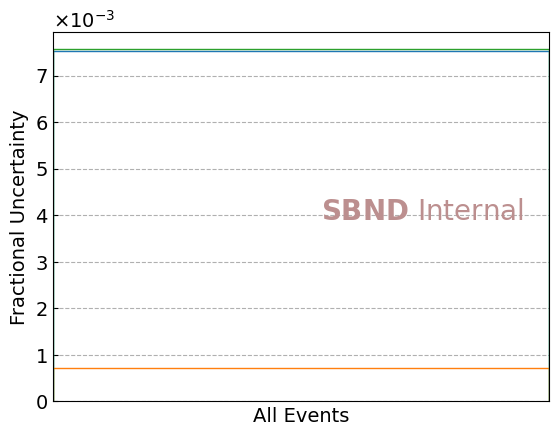

<Figure size 640x480 with 0 Axes>

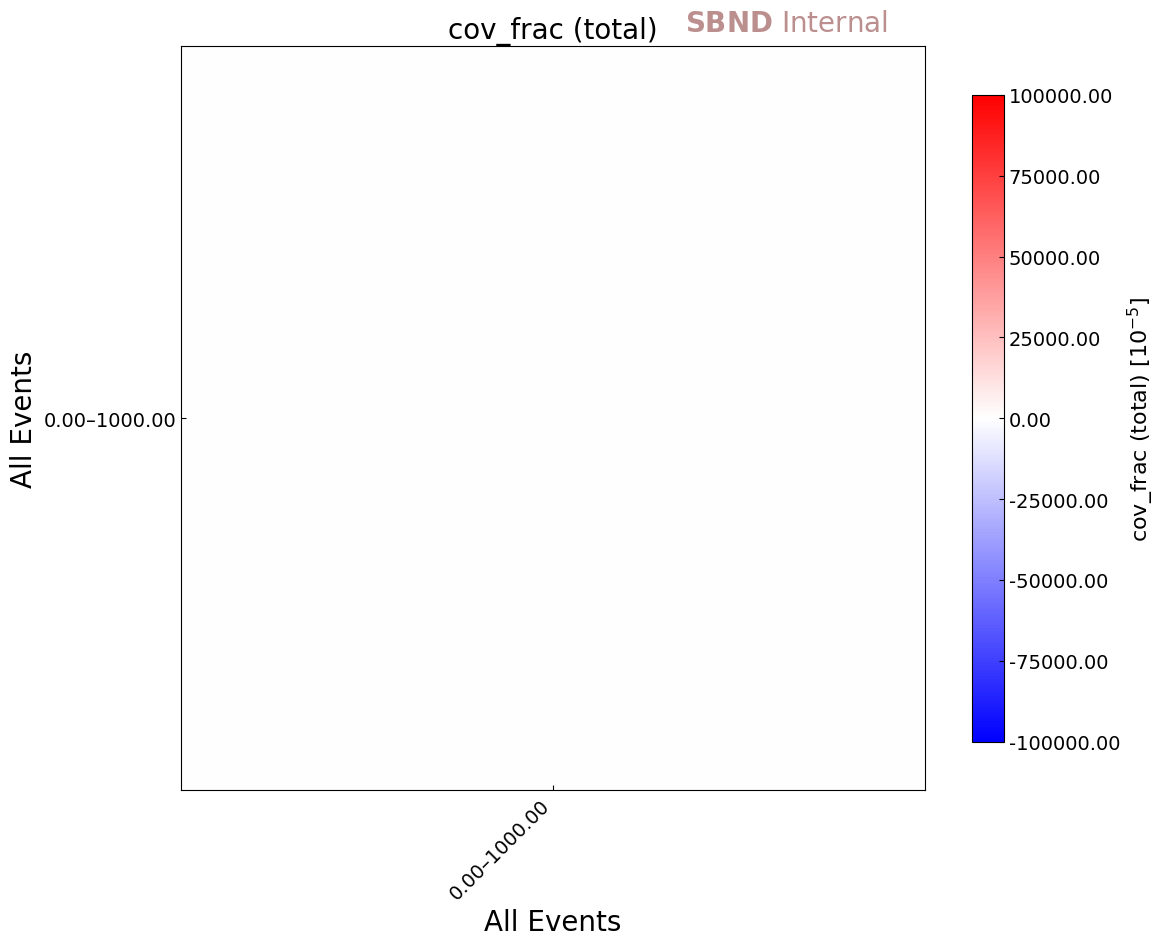

<Figure size 640x480 with 0 Axes>

[02:25:28]   done [xsec] GENIE/integrated in 7.9s


xsec vars (GENIE):  25%|██▌       | 1/4 [00:07<00:23,  7.90s/it]

[02:25:28] --- [xsec] GENIE variable [2/4] tki-del_Tp ---


[02:25:34]   total (indep sum of 2 knobs): mean frac unc=0.0221, max=0.0392
[02:25:34]   SKIP multiplied total for GENIE/tki-del_Tp: 'GENIE' (keeping indep-sum total)


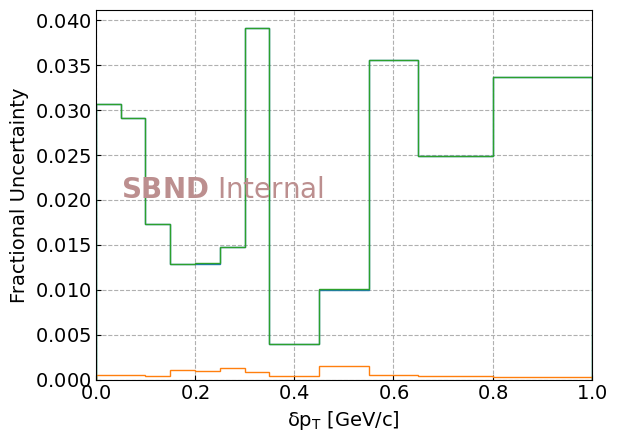

<Figure size 640x480 with 0 Axes>

[02:25:34]   done [xsec] GENIE/tki-del_Tp in 6.2s


xsec vars (GENIE):  50%|█████     | 2/4 [00:14<00:13,  6.92s/it]

[02:25:34] --- [xsec] GENIE variable [3/4] tki-del_alpha ---


[02:25:40]   total (indep sum of 2 knobs): mean frac unc=0.0175, max=0.0365
[02:25:40]   SKIP multiplied total for GENIE/tki-del_alpha: 'GENIE' (keeping indep-sum total)


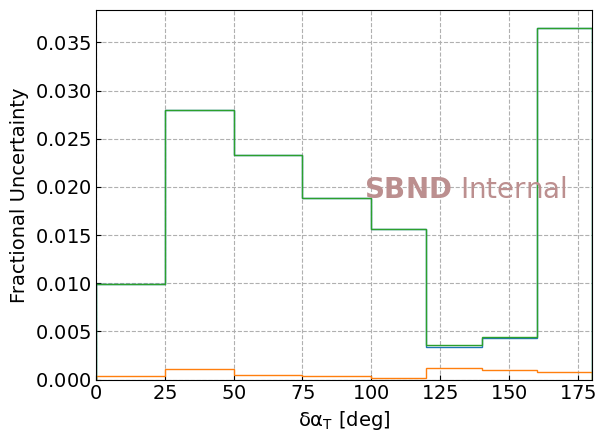

<Figure size 640x480 with 0 Axes>

[02:25:41]   done [xsec] GENIE/tki-del_alpha in 6.1s


xsec vars (GENIE):  75%|███████▌  | 3/4 [00:20<00:06,  6.54s/it]

[02:25:41] --- [xsec] GENIE variable [4/4] tki-del_phi ---


[02:25:46]   total (indep sum of 2 knobs): mean frac unc=0.0333, max=0.0907
[02:25:46]   SKIP multiplied total for GENIE/tki-del_phi: 'GENIE' (keeping indep-sum total)


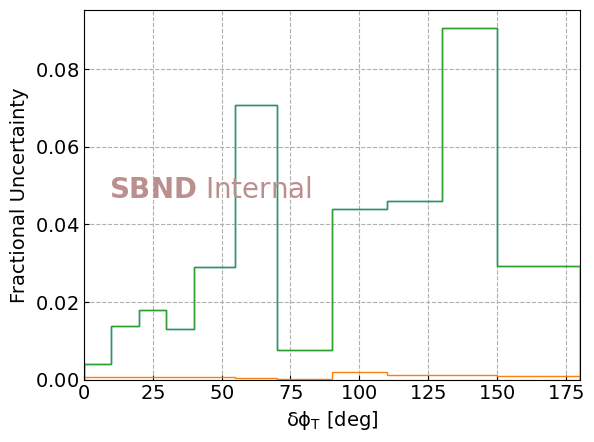

<Figure size 640x480 with 0 Axes>

[02:25:46]   done [xsec] GENIE/tki-del_phi in 5.9s


xsec vars (GENIE): 100%|██████████| 4/4 [00:26<00:00,  6.52s/it]

[02:25:46] FINISHED [xsec] GENIE: 4 variables in 26.1s
[02:25:46] GENIE variables: integrated, tki-del_Tp, tki-del_alpha, tki-del_phi
[02:25:46] cov_type=xsec done in 26.1s
[02:25:46] ######## cov_type=rate ########
[02:25:46] === [rate] category GENIE (2 knobs) ===
[02:25:46] dropping bad GENIE weights ...
[02:25:46] 1,462 events after cleaning (0 dropped) in 0.0s



rate vars (GENIE):   0%|          | 0/4 [00:00<?, ?it/s]

[02:25:46] --- [rate] GENIE variable [1/4] integrated ---


[02:25:52]   total (indep sum of 2 knobs): mean frac unc=0.0800, max=0.0800
[02:25:52]   SKIP multiplied total for GENIE/integrated: 'GENIE' (keeping indep-sum total)


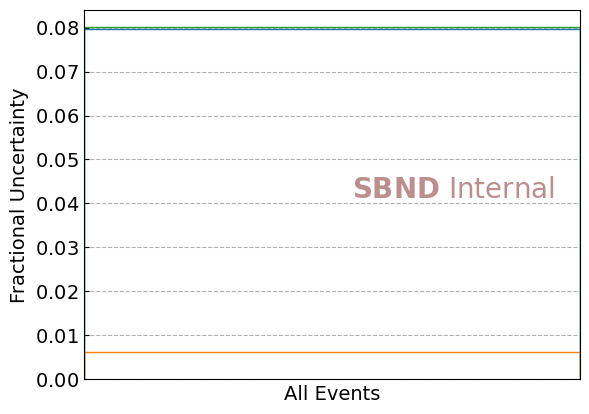

<Figure size 640x480 with 0 Axes>

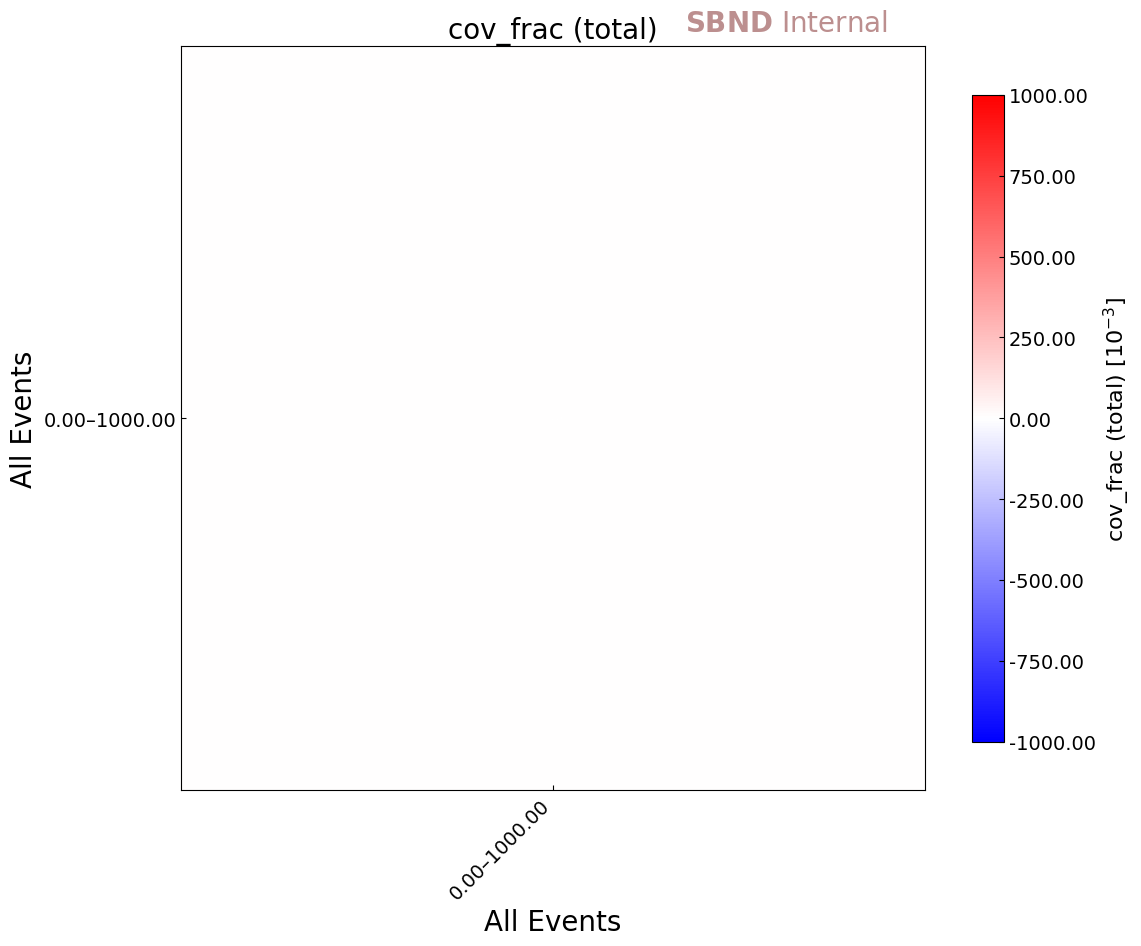

<Figure size 640x480 with 0 Axes>

[02:25:52]   done [rate] GENIE/integrated in 5.7s


rate vars (GENIE):  25%|██▌       | 1/4 [00:05<00:17,  5.71s/it]

[02:25:52] --- [rate] GENIE variable [2/4] tki-del_Tp ---


[02:25:58]   total (indep sum of 2 knobs): mean frac unc=0.0825, max=0.1305
[02:25:58]   SKIP multiplied total for GENIE/tki-del_Tp: 'GENIE' (keeping indep-sum total)


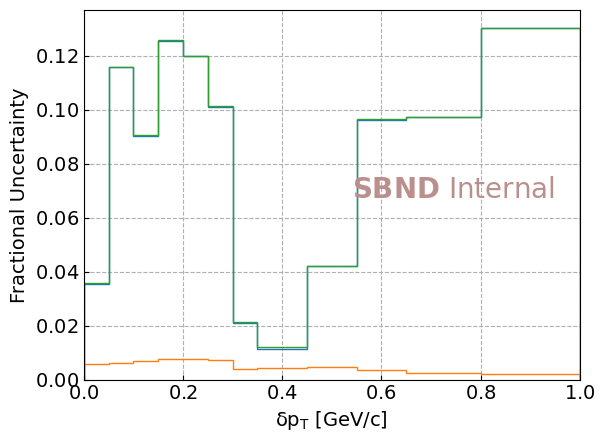

<Figure size 640x480 with 0 Axes>

[02:25:58]   done [rate] GENIE/tki-del_Tp in 5.8s


rate vars (GENIE):  50%|█████     | 2/4 [00:11<00:11,  5.74s/it]

[02:25:58] --- [rate] GENIE variable [3/4] tki-del_alpha ---


[02:26:04]   total (indep sum of 2 knobs): mean frac unc=0.0799, max=0.1227
[02:26:04]   SKIP multiplied total for GENIE/tki-del_alpha: 'GENIE' (keeping indep-sum total)


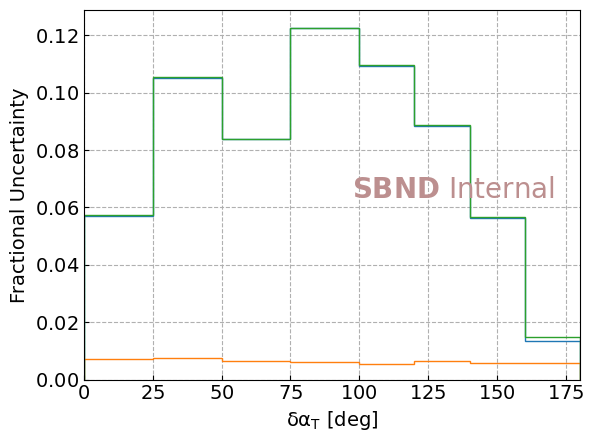

<Figure size 640x480 with 0 Axes>

[02:26:04]   done [rate] GENIE/tki-del_alpha in 6.2s


rate vars (GENIE):  75%|███████▌  | 3/4 [00:17<00:05,  5.95s/it]

[02:26:04] --- [rate] GENIE variable [4/4] tki-del_phi ---


[02:26:10]   total (indep sum of 2 knobs): mean frac unc=0.0806, max=0.1611
[02:26:10]   SKIP multiplied total for GENIE/tki-del_phi: 'GENIE' (keeping indep-sum total)


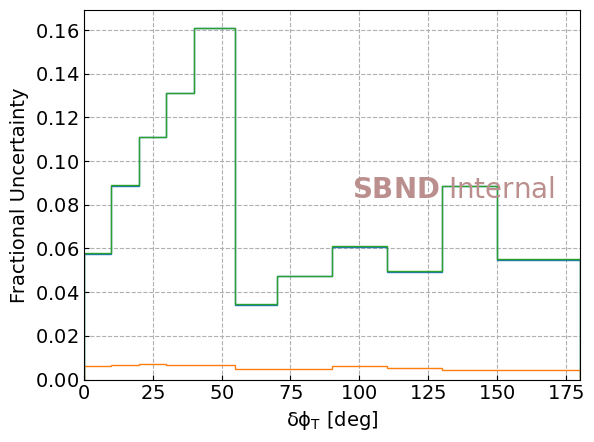

<Figure size 640x480 with 0 Axes>

[02:26:10]   done [rate] GENIE/tki-del_phi in 6.0s


rate vars (GENIE): 100%|██████████| 4/4 [00:23<00:00,  5.91s/it]

[02:26:10] FINISHED [rate] GENIE: 4 variables in 23.6s
[02:26:10] GENIE variables: integrated, tki-del_Tp, tki-del_alpha, tki-del_phi
[02:26:10] cov_type=rate done in 23.6s
[02:26:10] ALL cov_types done in 49.7s; default view cov_type=xsec


In [15]:
syst_dicts = {}
results_by_cov = {}
t_all = time.time()

for cov_type in COV_TYPES:
    _log(f'######## cov_type={cov_type} ########')
    syst_dict = {}
    results_by_syst_var = {}
    t_cov = time.time()

    for sn in SYST_TYPES:
        knobs = syst_knob_names(sn)
        knob_mode = bool(knobs)
        _log(f'=== [{cov_type}] category {sn} ({len(knobs)} knobs) ===')
        t_cat = time.time()

        _log(f'dropping bad {sn} weights ...')
        t_clean = time.time()
        mc_evt_df = drop_bad_weights(evtdf_by_syst[sn], sn, knobs, n_univ)
        n_drop = len(evtdf_by_syst[sn]) - len(mc_evt_df)
        _log(f'{len(mc_evt_df):,} events after cleaning ({n_drop:,} dropped) in {time.time() - t_clean:.1f}s')
        if len(mc_evt_df) == 0:
            raise RuntimeError(f'no events left after weight cleaning for {sn}')

        syst_dict[sn] = {}
        if knob_mode:
            syst_dict[f'{sn}_by_knob'] = {}

        first_var_done = False

        for ivar, var_config in enumerate(tqdm(var_configs, desc=f'{cov_type} vars ({sn})')):
            vsn = var_config.var_save_name
            t_var = time.time()
            _log(f'--- [{cov_type}] {sn} variable [{ivar + 1}/{len(var_configs)}] {vsn} ---')

            if not knob_mode:
                verbose_knob = VERBOSE_UNIV_LOOP and ivar == 0
                try:
                    pack, univ, cv = cov_pack_bundled(
                        mc_evt_df, var_config, sn, n_univ, cov_type, bkgd_subtract,
                        verbose=verbose_knob,
                    )
                except Exception as ex:
                    _log(f'  SKIP bundled {sn} for {vsn}: {ex}')
                    continue
                fu = frac_unc_from_pack(pack)
                syst_dict[sn][vsn] = pack
                results_by_syst_var[(sn, vsn)] = {'bundled': pack}
                _log(
                    f'  {sn}: mean frac unc={np.mean(fu):.4f}, max={np.max(fu):.4f}, '
                    f'{time.time() - t_var:.1f}s'
                )
                if PLOT_FRAC_UNC_EACH_VAR:
                    plot_frac_unc([fu], var_config)
                    plt.suptitle(f'[{cov_type}] {vsn}: {sn} fractional uncertainty', y=1.02)
                    plt.tight_layout()
                    plt.show()
                if PLOT_HEATMAP_FIRST_VAR and not first_var_done:
                    plot_heatmap(
                        pack['cov_frac'],
                        var_config.bins,
                        plot_labels=[var_config.var_labels[1], var_config.var_labels[1], f'cov_frac ({sn})'],
                        plot=True,
                    )
                    plt.suptitle(f'[{cov_type}] {vsn} {sn} cov_frac')
                    plt.tight_layout()
                    plt.show()
                    sk = resolve_bundled_syst_name(mc_evt_df, sn)
                    _univ_title = f'[{cov_type}] {vsn} {sn} universes'
                    plot_univ_hists(
                        univ, cv, sk, var_config,
                        ax_titles=['', '', _univ_title],
                        save_fig=SAVE_UNIV_HISTS,
                        save_name=univ_hist_save_name(sn, vsn, sn, cov_type) if SAVE_UNIV_HISTS else None,
                    )
                    plt.suptitle(_univ_title)
                    plt.tight_layout()
                    plt.show()
                    if PLOT_EFF_SMEAR_UNIVS and cov_type == 'xsec':
                        try:
                            response_pack = get_xsec_response_univs(
                                mc_evt_df, var_config, sn, n_univ, bkgd_subtract,
                                verbose=False,
                            )
                            plot_xsec_response_univ_hists(
                                response_pack,
                                sk,
                                var_config,
                                title_prefix=_univ_title,
                                save_fig=SAVE_UNIV_HISTS,
                                save_name_eff=univ_hist_save_name(sn, vsn, f'{sn}-eff', cov_type) if SAVE_UNIV_HISTS else None,
                                save_name_smear=univ_hist_save_name(sn, vsn, f'{sn}-smearing', cov_type) if SAVE_UNIV_HISTS else None,
                            )
                        except Exception as ex:
                            _log(f'  SKIP eff/smear universes for {sn}/{vsn}: {ex}')
                    first_var_done = True
                continue

            per_knob = {}
            frac_unc_curves = []
            knob_labels = []
            n_skip = 0

            for iknob, knob in enumerate(tqdm(knobs, desc=f'{cov_type} knobs {vsn}', leave=False)):
                try:
                    n_u = int(n_univ_by_knob.get(knob, n_univ)) if n_univ_by_knob else int(n_univ)
                    pack, univ, cv = cov_pack_for_knob(
                        mc_evt_df, var_config, knob, n_u, cov_type, bkgd_subtract,
                        verbose=False,
                    )
                except Exception as ex:
                    n_skip += 1
                    continue
                per_knob[knob] = pack
                fu = frac_unc_from_pack(pack)
                knob_labels.append(knob)
                frac_unc_curves.append(fu)
                do_univ_plot = PLOT_UNIV_EVERY_N_KNOBS and (iknob == 0 or (iknob + 1) % PLOT_UNIV_EVERY_N_KNOBS == 0)
                if do_univ_plot:
                    _univ_title = f'[{cov_type}] {sn} / {vsn} / {knob}'
                    plot_univ_hists(
                        univ, cv, ('mc', knob), var_config,
                        ax_titles=['', '', _univ_title],
                        save_fig=SAVE_UNIV_HISTS,
                        save_name=univ_hist_save_name(sn, vsn, knob, cov_type) if SAVE_UNIV_HISTS else None,
                    )
                    plt.suptitle(_univ_title, y=1.02)
                    plt.tight_layout()
                    plt.show()

            if not per_knob:
                _log(f'  no knobs succeeded for {sn}/{vsn} (skipped={n_skip})')
                continue

            if n_skip:
                _log(f'  knobs ok={len(per_knob)}/{len(knobs)} (skipped={n_skip})')

            # Production total = independent sum of per-knob cov_frac (always save this).
            pack_total = combine_indep_knob_packs(per_knob, cov_type=cov_type)
            fu_tot = frac_unc_from_pack(pack_total)
            _log(
                f'  total (indep sum of {len(per_knob)} knobs): mean frac unc={np.mean(fu_tot):.4f}, '
                f'max={np.max(fu_tot):.4f}'
            )

            pack_mult = None
            try:
                pack_mult, univ_tot, cv_tot = cov_pack_multiplied(
                    mc_evt_df, var_config, tuple(per_knob.keys()), n_univ, cov_type, bkgd_subtract,
                    bundled_tag=sn, verbose=False,
                )
                fu_mult = frac_unc_from_pack(pack_mult)
                _log(
                    f'  total (× weights): mean frac unc={np.mean(fu_mult):.4f}, max={np.max(fu_mult):.4f}'
                )
            except Exception as ex:
                _log(f'  SKIP multiplied total for {sn}/{vsn}: {ex} (keeping indep-sum total)')

            syst_dict[sn][vsn] = pack_total
            syst_dict[f'{sn}_by_knob'][vsn] = per_knob
            results_by_syst_var[(sn, vsn)] = {
                'per_knob': per_knob,
                'total_indep': pack_total,
                'total_mult': pack_mult,
            }

            frac_unc_curves.append(fu_tot)
            knob_labels.append('total (indep Σ)')
            if PLOT_FRAC_UNC_EACH_VAR:
                plot_frac_unc(frac_unc_curves, var_config)
                plt.suptitle(f'[{cov_type}] {sn} / {vsn}: per-knob + total fractional uncertainty', y=1.02)
                plt.tight_layout()
                plt.show()
            if PLOT_HEATMAP_FIRST_VAR and not first_var_done:
                plot_heatmap(
                    pack_total['cov_frac'],
                    var_config.bins,
                    plot_labels=[var_config.var_labels[1], var_config.var_labels[1], 'cov_frac (total)'],
                    plot=True,
                )
                plt.suptitle(f'[{cov_type}] {sn} / {vsn} total cov_frac (indep Σ)')
                plt.tight_layout()
                plt.show()
                if pack_mult is not None:
                    _univ_title = f'[{cov_type}] {sn} / {vsn} total multiplied weights'
                    plot_univ_hists(
                        univ_tot, cv_tot, ('mc', sn), var_config,
                        ax_titles=['', '', _univ_title],
                        save_fig=SAVE_UNIV_HISTS,
                        save_name=univ_hist_save_name(sn, vsn, 'total-mult', cov_type) if SAVE_UNIV_HISTS else None,
                    )
                    plt.suptitle(_univ_title)
                    plt.tight_layout()
                    plt.show()
                first_var_done = True

            _log(f'  done [{cov_type}] {sn}/{vsn} in {time.time() - t_var:.1f}s')

        _log(f'FINISHED [{cov_type}] {sn}: {len(syst_dict[sn])} variables in {time.time() - t_cat:.1f}s')
        _log(f'{sn} variables: ' + ', '.join(sorted(syst_dict[sn].keys())))

    syst_dicts[cov_type] = syst_dict
    results_by_cov[cov_type] = results_by_syst_var
    _log(f'cov_type={cov_type} done in {time.time() - t_cov:.1f}s')

# Convenience aliases for downstream cells (prefer xsec if present)
cov_type = 'xsec' if 'xsec' in syst_dicts else COV_TYPES[0]
syst_dict = syst_dicts[cov_type]
results_by_syst_var = results_by_cov[cov_type]
_log(f'ALL cov_types done in {time.time() - t_all:.1f}s; default view cov_type={cov_type}')


In [16]:
import pickle

_log('writing NPZ(s) + GENIE cov_mat_dict.pkl ...')
from analysis_village.numucc_1p0pi.syst_disk_layout import (
    SUB_MCSTAT, FILE_MCSTAT, SUB_FLUX, FILE_FLUX, SUB_G4, FILE_G4,
    SUB_GENIE, FILE_GENIE,
)

# Per cov_type tree: <SYST_DISK_ROOT>/<xsec|rate>/GENIE/...
for ct, sd in syst_dicts.items():
    out_root = os.path.join(SYST_DISK_ROOT, ct)
    os.makedirs(out_root, exist_ok=True)
    save_neutrino_multisim_npzs(sd, out_root)
    for sn in SYST_TYPES:
        if not sd.get(sn):
            continue
        _paths = {
            'MCstat': (SUB_MCSTAT, FILE_MCSTAT),
            'Flux': (SUB_FLUX, FILE_FLUX),
            'G4': (SUB_G4, FILE_G4),
            'GENIE': (SUB_GENIE, FILE_GENIE),
        }
        sub, fname = _paths[sn]
        npz_path = os.path.join(normalized_root(out_root), sub, fname)
        _log(f'  wrote [{ct}] {npz_path}')


def build_genie_cov_mat_dict(syst_dicts_in):
    """Production-style pickle: per var → genie / genie_rate + per-knob (+ _rate)."""
    xsec_sd = syst_dicts_in.get('xsec', {})
    rate_sd = syst_dicts_in.get('rate', {})
    vsns = set()
    for sd in (xsec_sd, rate_sd):
        vsns.update(sd.get('GENIE', {}).keys())
    out = {}
    for vsn in sorted(vsns):
        row = {}
        if vsn in xsec_sd.get('GENIE', {}):
            row['genie'] = np.asarray(xsec_sd['GENIE'][vsn]['cov_frac'], dtype=np.float64)
        if vsn in rate_sd.get('GENIE', {}):
            row['genie_rate'] = np.asarray(rate_sd['GENIE'][vsn]['cov_frac'], dtype=np.float64)
        for kn, pack in (xsec_sd.get('GENIE_by_knob', {}).get(vsn) or {}).items():
            if isinstance(pack, dict) and 'cov_frac' in pack:
                row[kn] = np.asarray(pack['cov_frac'], dtype=np.float64)
        for kn, pack in (rate_sd.get('GENIE_by_knob', {}).get(vsn) or {}).items():
            if isinstance(pack, dict) and 'cov_frac' in pack:
                row[f'{kn}_rate'] = np.asarray(pack['cov_frac'], dtype=np.float64)
        out[vsn] = row
    return out


cov_mat_dict = build_genie_cov_mat_dict(syst_dicts)
genie_dir = os.path.join(normalized_root(SYST_DISK_ROOT), SUB_GENIE)
os.makedirs(genie_dir, exist_ok=True)
pkl_path = os.path.join(genie_dir, FILE_GENIE)
with open(pkl_path, 'wb') as f:
    pickle.dump(cov_mat_dict, f, protocol=pickle.HIGHEST_PROTOCOL)
_log(f'wrote combined GENIE pickle {pkl_path} ({len(cov_mat_dict)} vars)')

categories_present = sorted({
    sn for sd in syst_dicts.values() for sn in SYST_TYPES if sd.get(sn)
})
knob_sidecars = sorted({
    f'{sn}_by_knob'
    for sd in syst_dicts.values()
    for sn in SYST_TYPES
    if sd.get(f'{sn}_by_knob')
})
var_names = set()
for sd in syst_dicts.values():
    for sn in categories_present:
        var_names.update(sd.get(sn, {}).keys())

_knob_total_method = {}
for sn in categories_present:
    if sn in ('Flux', 'G4'):
        _knob_total_method[sn] = 'multiply_univ_weights'
    elif sn == 'GENIE':
        _knob_total_method[sn] = 'independent_sum_cov_frac'

manifest = {
    'schema': 'numucc_multisim_covariance_v1',
    'description': (
        'Notebook multisim syst for xsec + rate. Per-cov_type NPZs under <root>/<cov_type>/; '
        'combined GENIE/cov_mat_dict.pkl uses genie (xsec) + genie_rate keys.'
    ),
    'mc_df_stage': MC_DF_STAGE,
    'var_set': 'notebook',
    'syst_types_run': list(SYST_TYPES),
    'cov_types': list(COV_TYPES),
    'categories_present': categories_present,
    'knob_breakdown_sidecars': knob_sidecars,
    'variables': sorted(var_names),
    'knob_total_method': _knob_total_method,
    'n_univ': n_univ,
    'bkgd_subtract': bkgd_subtract,
    'genie_cov_mat_dict': pkl_path,
    'knobs': {sn: list(syst_knob_names(sn)) for sn in SYST_TYPES if syst_knob_names(sn)},
}
manifest_path = os.path.join(normalized_root(SYST_DISK_ROOT), 'covariance_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
_log('wrote ' + manifest_path)


[02:26:10] writing NPZ(s) + GENIE cov_mat_dict.pkl ...
[02:26:10]   wrote [xsec] /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/xsec/GENIE/cov_mat_dict.pkl
[02:26:10]   wrote [rate] /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/rate/GENIE/cov_mat_dict.pkl
[02:26:10] wrote combined GENIE pickle /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/GENIE/cov_mat_dict.pkl (4 vars)
[02:26:10] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/covariance_manifest.json


[02:26:10] inspect [xsec]: GENIE/tki-del_phi (available=['integrated', 'tki-del_Tp', 'tki-del_alpha', 'tki-del_phi'])


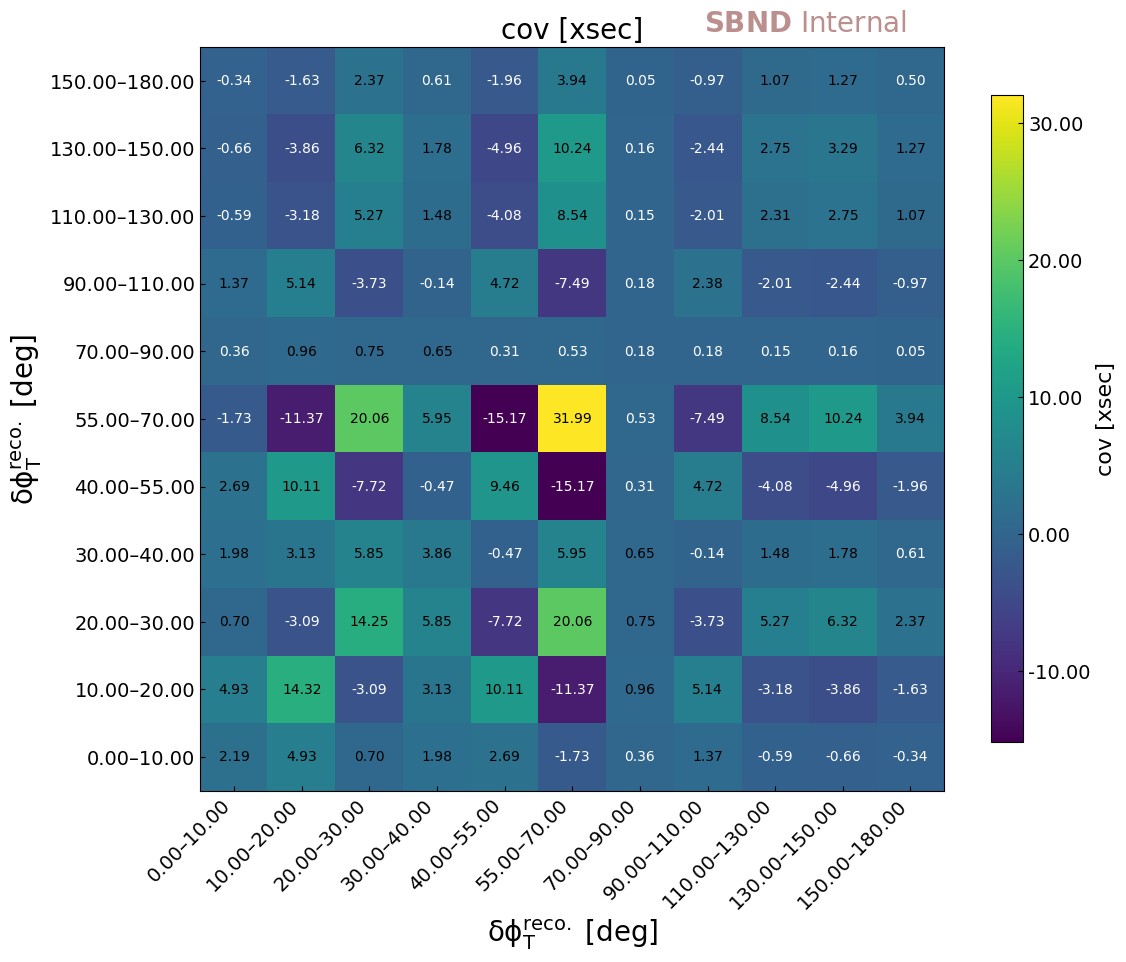

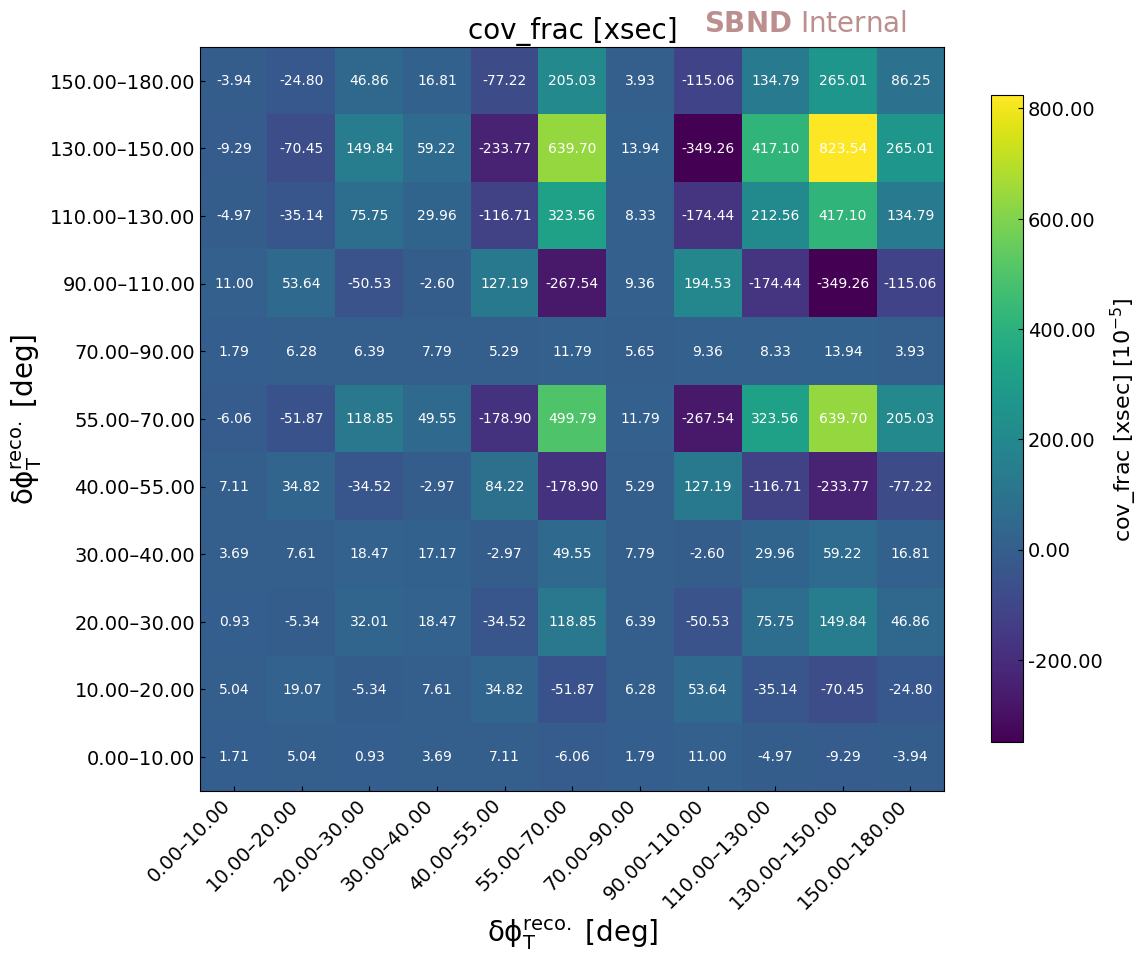

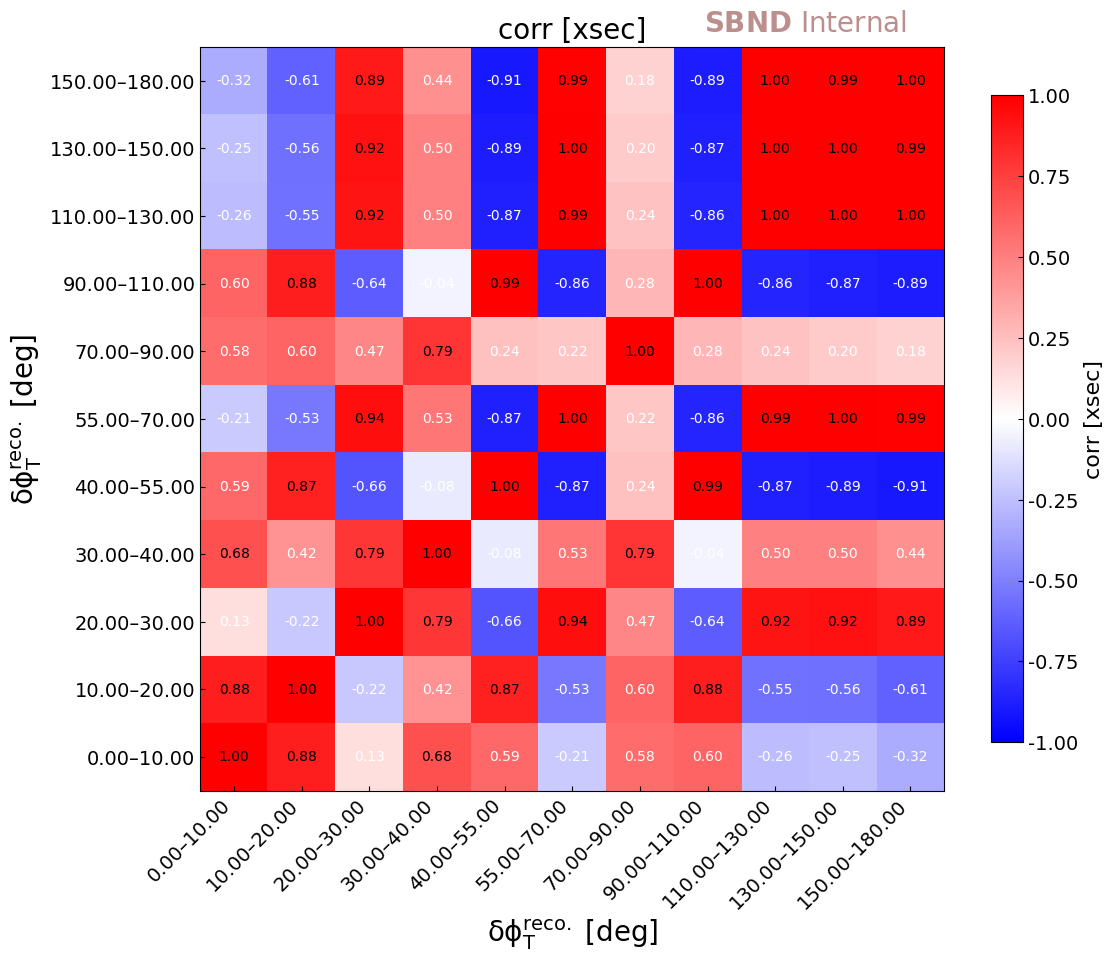

[xsec] GENIE/tki-del_phi sqrt(diag(cov_frac)): [0.00414103 0.01381058 0.0178904  0.01310195 0.0290208  0.07069601
 0.00751569 0.04410544 0.04610372 0.09074894 0.02936783]
[02:26:12] inspect [rate]: GENIE/tki-del_phi (available=['integrated', 'tki-del_Tp', 'tki-del_alpha', 'tki-del_phi'])


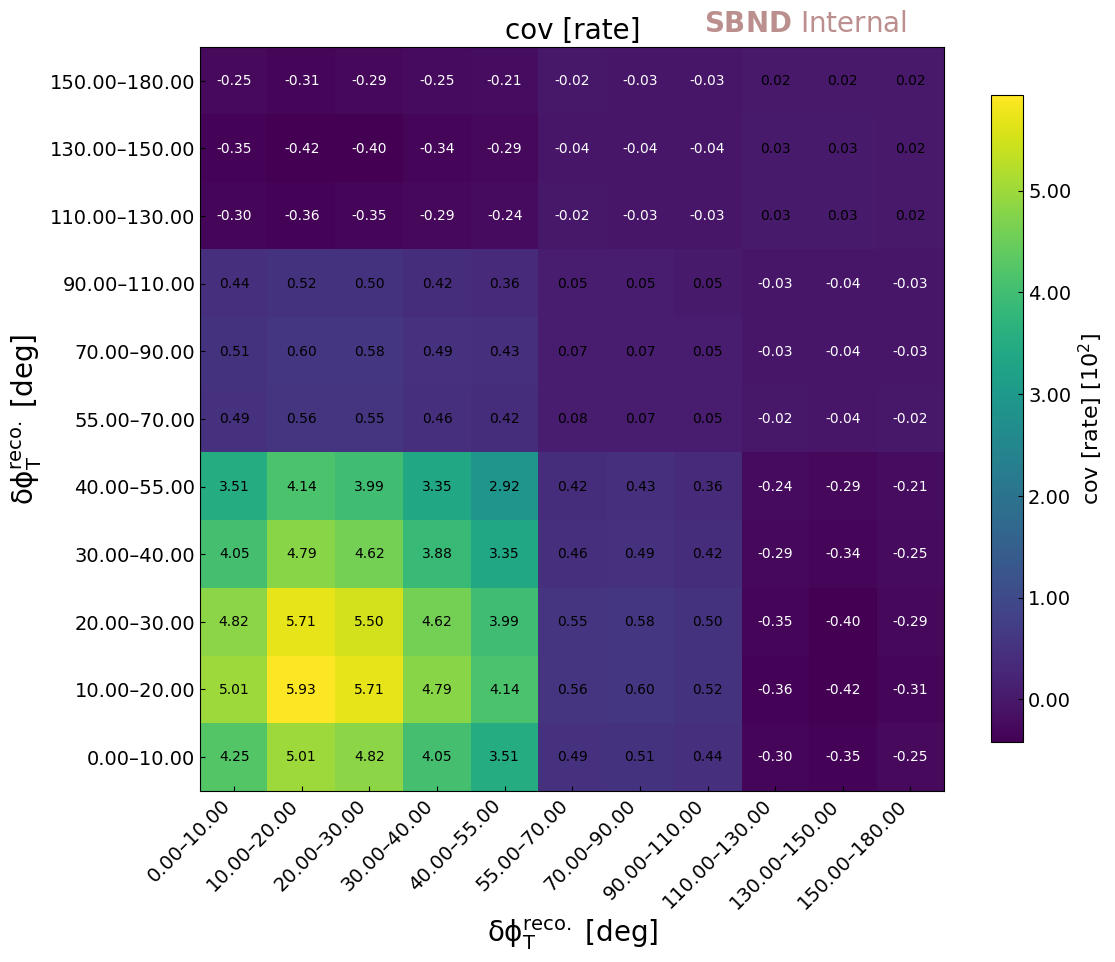

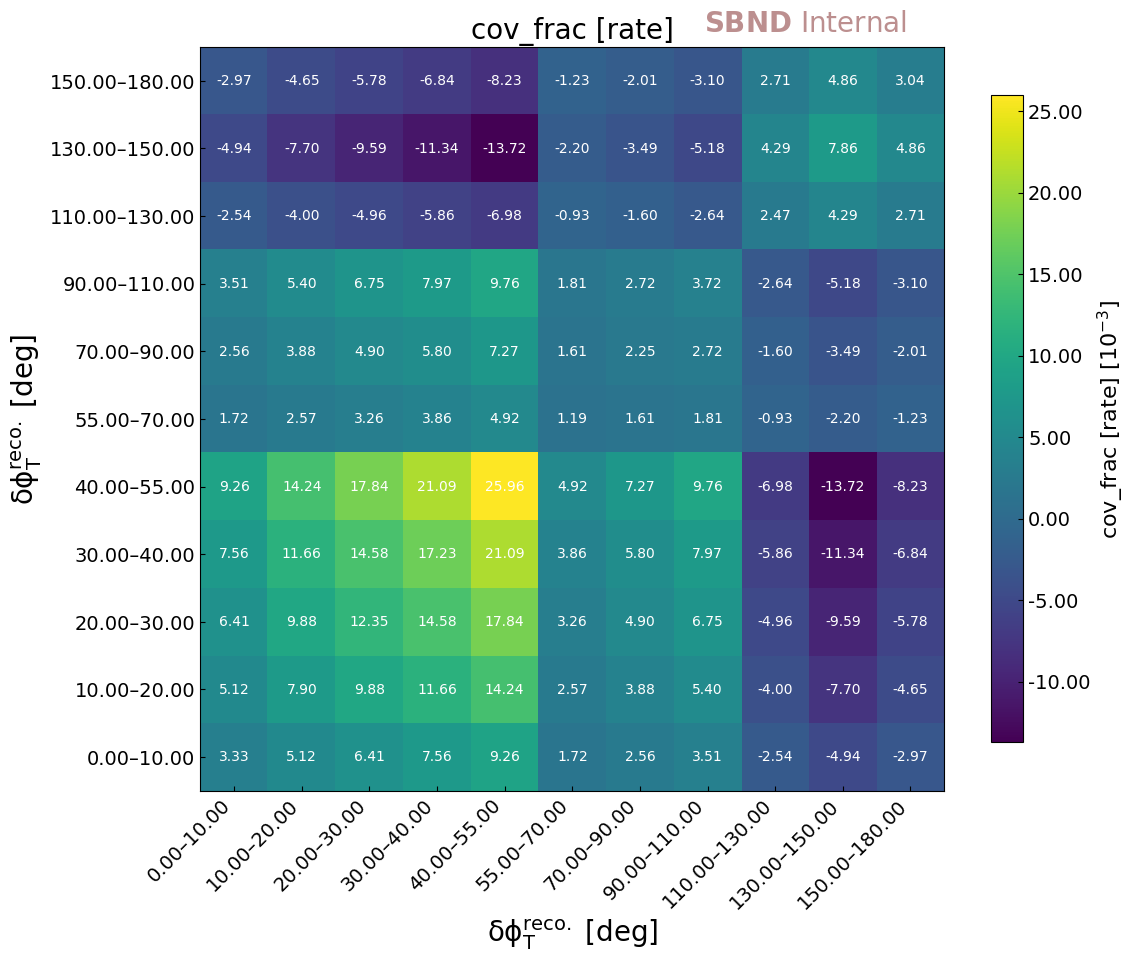

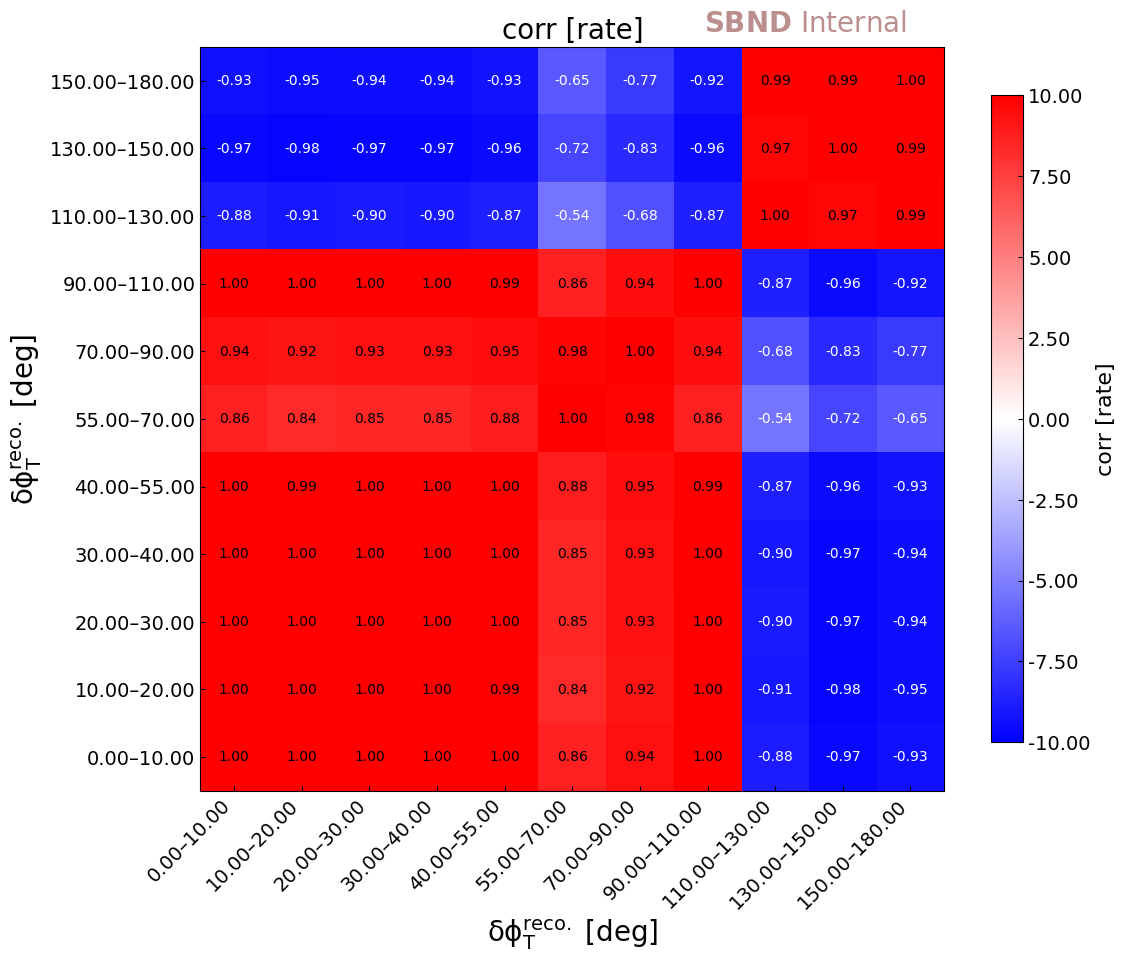

[rate] GENIE/tki-del_phi sqrt(diag(cov_frac)): [0.05771362 0.08890984 0.11111518 0.13127041 0.16110706 0.03455576
 0.04747625 0.06101615 0.04966454 0.08866209 0.0551292 ]


In [17]:
# Optional: inspect one variable (matrices + per-bin fractional uncertainty)
INSPECT_SYST = SYST_TYPES[-1]
INSPECT_COV_TYPES = list(COV_TYPES)

for _ct in INSPECT_COV_TYPES:
    _sd = syst_dicts.get(_ct, {})
    _available = sorted(_sd.get(INSPECT_SYST, {}).keys())
    if not _available:
        _log(f'inspect [{_ct}]: syst_dicts[{_ct!r}][{INSPECT_SYST!r}] empty — skip')
        continue

    _want = var_configs[-1].var_save_name
    inspect_var = _want if _want in _sd[INSPECT_SYST] else _available[0]
    if inspect_var != _want:
        _log(f'inspect [{_ct}]: {_want!r} missing; using {inspect_var!r} (available={_available})')
    else:
        _log(f'inspect [{_ct}]: {INSPECT_SYST}/{inspect_var} (available={_available})')

    pack = _sd[INSPECT_SYST][inspect_var]
    vc = next(v for v in var_configs if v.var_save_name == inspect_var)

    for matrix_type in ('cov', 'cov_frac', 'corr'):
        mat = np.asarray(pack[matrix_type], dtype=float)
        if mat.shape[0] != len(vc.bins) - 1:
            _log(
                f'SKIP heatmap [{_ct}] {matrix_type}: matrix {mat.shape} vs bins len={len(vc.bins)} '
                f'(need n_bins-1={len(vc.bins)-1})'
            )
            continue
        cmap = 'bwr' if matrix_type == 'corr' else 'viridis'
        plot_heatmap(
            mat,
            vc.bins,
            plot_labels=[vc.var_labels[1], vc.var_labels[1], f'{matrix_type} [{_ct}]'],
            plot=True,
            save_fig=False,
            cmap=cmap,
        )
        plt.show()

    print(f'[{_ct}] {INSPECT_SYST}/{inspect_var} sqrt(diag(cov_frac)):', frac_unc_from_pack(pack))


## Uncertainty breakdown plots

Per-variable **1×2** fractional-uncertainty panels (CCQE has no family structure):

| **xsec** (left) | **rate** (right) |
|---|---|
| per-knob + Total | per-knob + Total |

**Total** = ``sqrt(diag(Σ_k cov_frac_k))`` (independent-knob sum).
Also a compact overview: one 2×2 of the four analysis variables for **xsec** and one for **rate**.


In [18]:
import re

BREAKDOWN_TOP_N = 12          # max individual knob curves in legend (Total always shown)
BREAKDOWN_SAVE_FIGS = True
BREAKDOWN_FIG_DPI = 140


def _frac_unc_pct(cov_frac):
    c = np.asarray(cov_frac, dtype=np.float64)
    return 100.0 * np.sqrt(np.maximum(np.diag(c), 0.0))


def _short_knob_label(knob: str) -> str:
    kn = str(knob)
    for pfx in (
        "GENIEReWeight_SBN_v1_multisim_",
        "GENIEReWeight_SBN_v1_multisigma_",
        "GENIEReWeight_SBN_v3_",
        "GENIEReWeight_",
        "CCQETemplateReweight_SBN_v3_",
        "CCQETemplateReweight_",
        "QEInterference_SBN_v3_",
        "QEInterference_",
        "ZExpPCAWeighter_SBN_v3_",
        "ZExpPCAWeighter_",
        "MECq0q3InterpWeighting_SBN_v3_",
        "MECq0q3InterpWeighting_",
        "CCQEXSecCorr_SBN_v3_",
        "CCQEXSecCorr_",
    ):
        if kn.startswith(pfx):
            kn = kn[len(pfx):]
            break
    for tok in ("_multisim", "_multisigma", "_SBN_v1", "_SBN_v3"):
        kn = kn.replace(tok, "")
    while "__" in kn:
        kn = kn.replace("__", "_")
    return kn.strip("_").replace("_", " ")


def _family_group_key(knob: str) -> str:
    """Collapse multi-component families (unused for CCQE) (q0bins, dials, MvA b's)."""
    kn = str(knob)
    if "MvA" in kn and re.search(r"_b\d+$", kn):
        return "MvA"
    if "ZExp" in kn and re.search(r"_b\d+$", kn) and "MvA" not in kn:
        return "ZExp"
    m = re.search(r"_dial_\d+$", kn)
    if m:
        return _short_knob_label(kn[: m.start()])
    m = re.search(r"_q0bin\d+$", kn)
    if m:
        prefix = kn[: m.start()]
        if "Martini" in prefix:
            return "MEC Martini"
        if "Valenica" in prefix or "Valencia" in prefix:
            return "MEC Valencia"
        return _short_knob_label(prefix)
    return _short_knob_label(kn)


def collect_breakdown_parts(per_knob_packs, *, group_families=False):
    """Return ``{label: cov_frac}`` and the independent-sum total cov_frac."""
    parts = {}
    for kn, pack in (per_knob_packs or {}).items():
        if not isinstance(pack, dict) or pack.get("cov_frac") is None:
            continue
        mat = np.asarray(pack["cov_frac"], dtype=np.float64)
        label = _family_group_key(kn) if group_families else _short_knob_label(kn)
        parts[label] = mat.copy() if label not in parts else parts[label] + mat
    if not parts:
        return {}, None
    total = None
    for mat in parts.values():
        total = mat.copy() if total is None else total + mat
    return parts, total


def plot_uncertainty_breakdown(
    ax,
    var_config,
    parts,
    total_cov_frac,
    *,
    title="",
    top_n=BREAKDOWN_TOP_N,
    ylabel=None,
    cov_type_label=None,
):
    """Step histograms of fractional unc [%] for grouped sources + Total."""
    if not parts and total_cov_frac is None:
        ax.set_title(title + " (empty)")
        return

    scores = {k: float(np.mean(_frac_unc_pct(m))) for k, m in parts.items()}
    ordered = sorted(scores, key=scores.get, reverse=True)
    show = ordered[: max(int(top_n), 0)]
    cmap = plt.cm.tab20(np.linspace(0, 1, max(len(show), 1)))

    centers = np.asarray(var_config.bin_centers, float)
    bins = np.asarray(var_config.bins, float)
    is_int = var_config.var_save_name == "integrated"

    for i, lab in enumerate(show):
        w = _frac_unc_pct(parts[lab])
        if is_int:
            w = np.full_like(w, float(w[0]))
        ax.hist(
            centers,
            bins=bins,
            weights=w,
            histtype="step",
            linewidth=1.3,
            color=cmap[i % len(cmap)],
            label=f"{lab} ({scores[lab]:.2f}%)",
        )

    if total_cov_frac is not None:
        wtot = _frac_unc_pct(total_cov_frac)
        if is_int:
            wtot = np.full_like(wtot, float(wtot[0]))
        ax.hist(
            centers,
            bins=bins,
            weights=wtot,
            histtype="step",
            linewidth=2.6,
            color="k",
            label=f"Total ({float(np.mean(wtot)):.2f}%)",
        )

    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel(var_config.var_labels[1] if var_config.var_labels else var_config.var_save_name)
    ax.set_ylabel(ylabel or f"frac. unc. on {cov_type_label or cov_type} [%]")
    ax.set_title(title)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, ncol=2, loc="best", framealpha=0.9)
    if is_int:
        # single-bin: cleaner x ticks
        ax.set_xticks([centers[0]])
        ax.set_xticklabels(["integrated"])




def _syst_dict_nonempty(sd):
    return any(bool(sd.get(sn)) for sn in SYST_TYPES)


def _load_syst_dict_from_npz(npz_path, sn="GENIE"):
    """Rebuild ``{sn: {vsn: pack}, sn_by_knob: {vsn: {knob: pack}}}`` from legacy NPZ."""
    blob = np.load(npz_path, allow_pickle=True)
    out = {sn: {}, f"{sn}_by_knob": {}}
    for vsn in blob.files:
        cell = blob[vsn].item()
        if not isinstance(cell, dict):
            continue
        if sn in cell and isinstance(cell[sn], dict) and "cov_frac" in cell[sn]:
            out[sn][vsn] = cell[sn]
        bk = cell.get(f"{sn}_by_knob")
        if isinstance(bk, dict) and bk:
            out[f"{sn}_by_knob"][vsn] = bk
    if not out[sn]:
        return {}
    if not out[f"{sn}_by_knob"]:
        out.pop(f"{sn}_by_knob", None)
    return out


def _load_syst_dicts_from_disk(root):
    """Prefer ``<root>/<cov_type>/GENIE/...``; fall back to ``<root>/GENIE/...`` as xsec."""
    root = Path(normalized_root(root))
    loaded = {}
    for ct in COV_TYPES:
        for cand in (
            root / ct / "GENIE" / "cov_mat_dict.pkl.npz",
            root / ct / "GENIE" / "cov_mat_dict.pkl",
            root / ct / "GENIE" / "cov_mat_dict.npz",
        ):
            if cand.is_file() and cand.stat().st_size > 64:
                try:
                    sd = _load_syst_dict_from_npz(str(cand))
                except Exception:
                    continue
                if _syst_dict_nonempty(sd):
                    loaded[ct] = sd
                    _log(f"breakdown: loaded [{ct}] from {cand}")
                    break
    if loaded:
        return loaded
    # Single-tree fallback (older notebook save) → treat as first cov type / pack cov_type
    for cand in (
        root / "GENIE" / "cov_mat_dict.pkl.npz",
        root / "GENIE" / "cov_mat_dict.npz",
        root / "GENIE" / "cov_mat_dict.pkl",
    ):
        if not (cand.is_file() and cand.stat().st_size > 64):
            continue
        try:
            sd = _load_syst_dict_from_npz(str(cand))
        except Exception:
            continue
        if not _syst_dict_nonempty(sd):
            continue
        # Infer cov_type from pack metadata when present
        ct = COV_TYPES[0]
        for pack in sd.get("GENIE", {}).values():
            if isinstance(pack, dict) and pack.get("cov_type") in ("xsec", "rate"):
                ct = pack["cov_type"]
                break
        loaded[ct] = sd
        _log(f"breakdown: loaded fallback [{ct}] from {cand}")
        break
    return loaded


def ensure_syst_dicts_for_breakdown():
    """Fill ``syst_dicts`` / ``results_by_cov`` from memory or disk if the dual-run dicts are empty."""
    global syst_dicts, results_by_cov, syst_dict, results_by_syst_var, cov_type

    if "syst_dicts" not in globals() or not isinstance(syst_dicts, dict):
        syst_dicts = {}
    if "results_by_cov" not in globals() or not isinstance(results_by_cov, dict):
        results_by_cov = {}

    if any(_syst_dict_nonempty(syst_dicts.get(ct, {})) for ct in COV_TYPES):
        return

    # Legacy single-cov in-memory run
    if "syst_dict" in globals() and _syst_dict_nonempty(syst_dict):
        ct = cov_type if "cov_type" in globals() and cov_type in ("xsec", "rate") else COV_TYPES[0]
        syst_dicts = {ct: syst_dict}
        results_by_cov = {
            ct: (results_by_syst_var if "results_by_syst_var" in globals() else {})
        }
        _log(f"breakdown: using in-memory syst_dict as [{ct}] only")
        return

    loaded = _load_syst_dicts_from_disk(SYST_DISK_ROOT)
    if loaded:
        syst_dicts = loaded
        # Rebuild minimal results_by_cov so breakdown can find packs
        results_by_cov = {}
        for ct, sd in syst_dicts.items():
            res = {}
            for vsn, pack in sd.get("GENIE", {}).items():
                block = {"total_indep": pack}
                bk = (sd.get("GENIE_by_knob") or {}).get(vsn)
                if bk:
                    block["per_knob"] = bk
                res[("GENIE", vsn)] = block
            results_by_cov[ct] = res
        return

    raise RuntimeError(
        "No GENIE results in memory or under SYST_DISK_ROOT for breakdown.\n"
        f"  SYST_DISK_ROOT={normalized_root(SYST_DISK_ROOT)}\n"
        "  Re-run the covariance loop cell (builds syst_dicts for xsec + rate), "
        "then the NPZ/save cell, then this plotter."
    )


def resolve_breakdown_parts(cov_type, sn, vsn, *, group_families=True):
    """Return ``(parts, total, per_knob)`` for one cov_type / variable."""
    results = results_by_cov.get(cov_type, {})
    syst_dict = syst_dicts.get(cov_type, {})
    block = results.get((sn, vsn), {})
    per_knob = block.get("per_knob")
    if not per_knob:
        pack = block.get("bundled") or block.get("total_indep") or syst_dict.get(sn, {}).get(vsn)
        if pack is None:
            return {}, None, None
        parts = {sn: np.asarray(pack["cov_frac"], float)}
        return parts, parts[sn], None
    parts, total = collect_breakdown_parts(per_knob, group_families=group_families)
    return parts, total, per_knob


def breakdown_outdir(cov_type=None):
    out = Path(normalized_root(SYST_DISK_ROOT)) / "breakdown"
    if cov_type is not None:
        out = out / str(cov_type)
    out.mkdir(parents=True, exist_ok=True)
    return out


_log(
    f"breakdown helpers ready (top_n={BREAKDOWN_TOP_N}, save={BREAKDOWN_SAVE_FIGS}, "
    f"out={breakdown_outdir()})"
)


[02:26:13] breakdown helpers ready (top_n=12, save=True, out=/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown)


[02:26:13] breakdown using cov_types=xsec(4 vars), rate(4 vars)
[02:26:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/break_xsec_rate__integrated.png


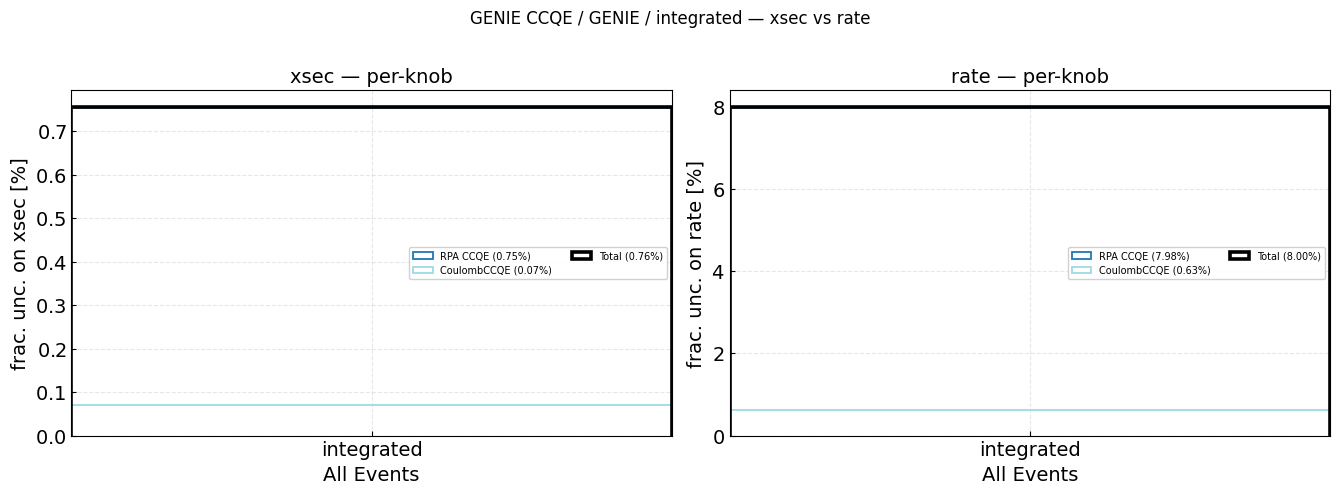

[02:26:14] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/break_xsec_rate__tki-del_Tp.png


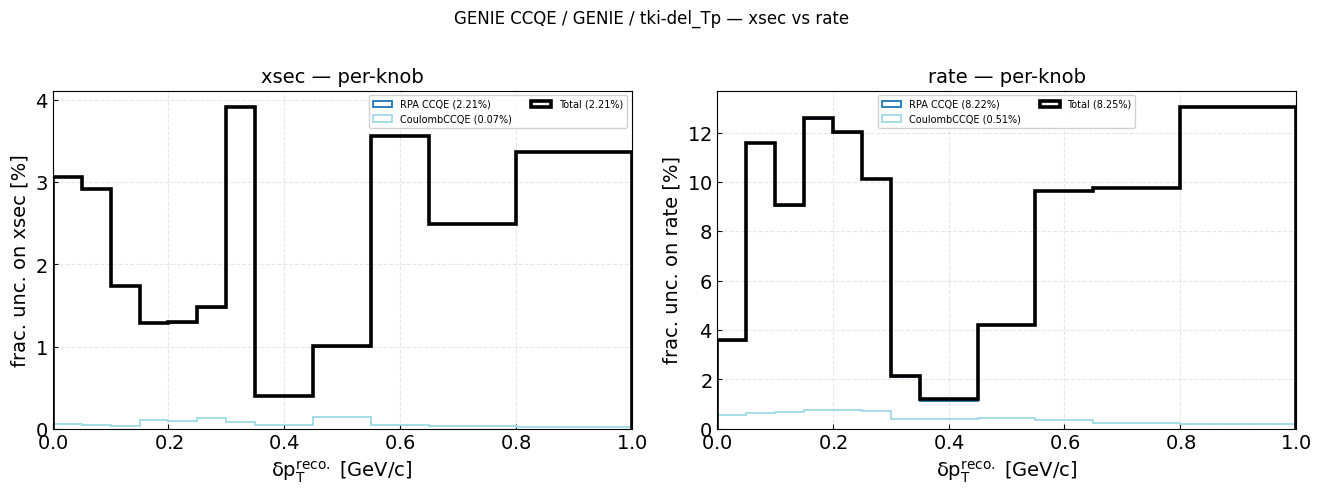

[02:26:15] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/break_xsec_rate__tki-del_alpha.png


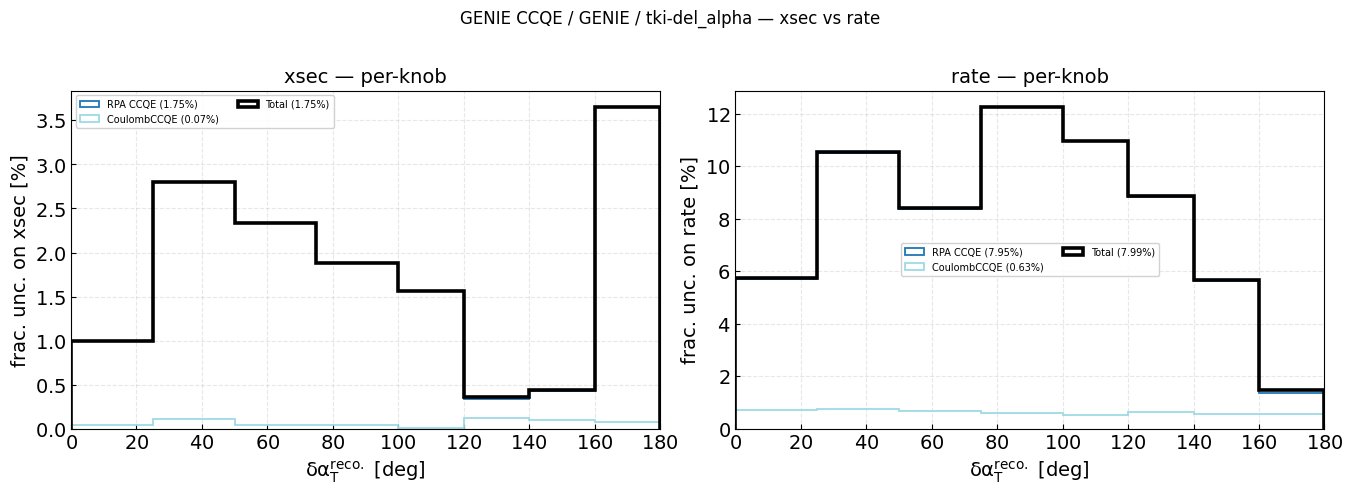

[02:26:16] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/break_xsec_rate__tki-del_phi.png


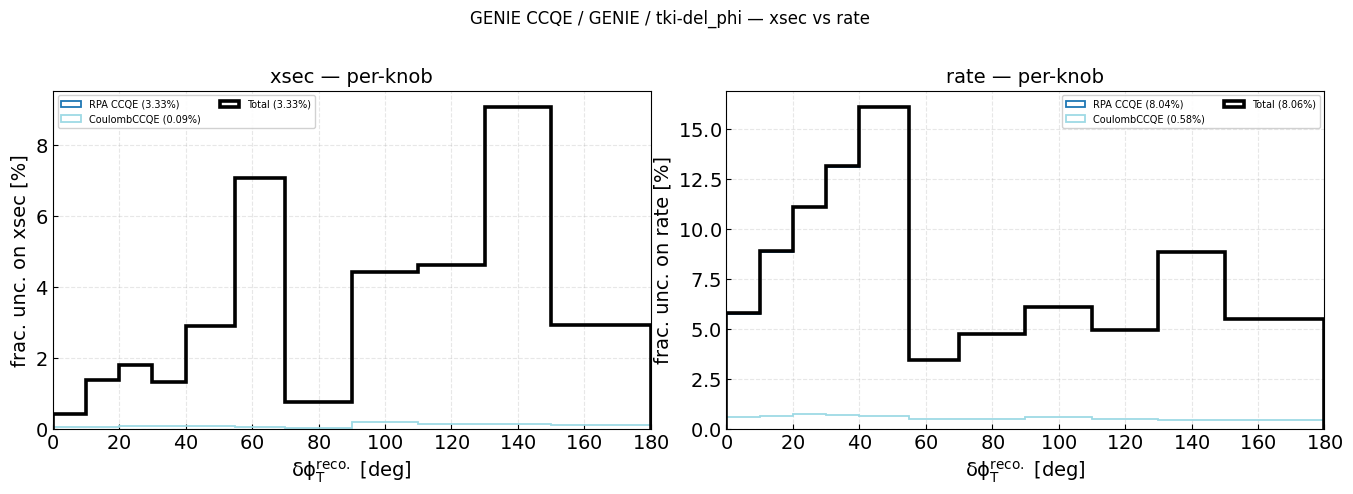

[02:26:18] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/xsec/break_xsec__overview_2x2.png


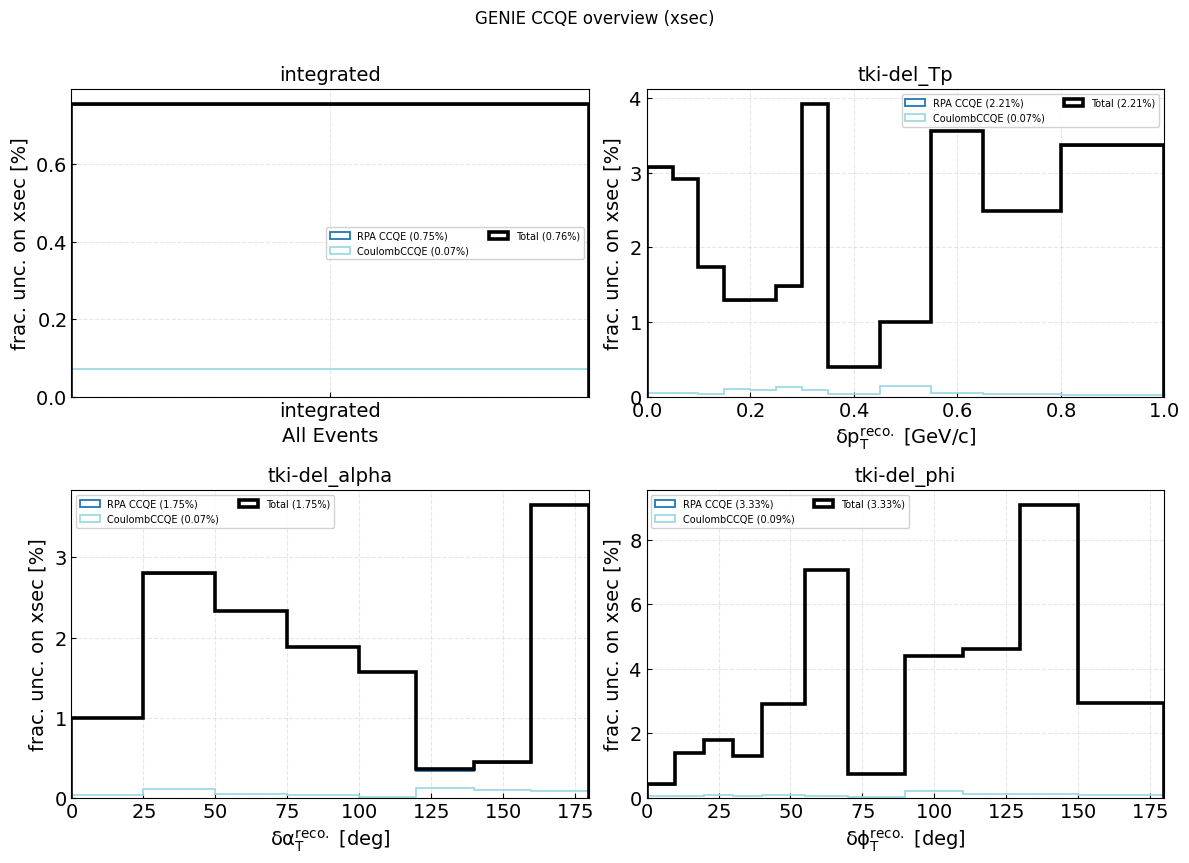

[02:26:19] wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-notebook-CCQE-sel_mup-20260910/breakdown/rate/break_rate__overview_2x2.png


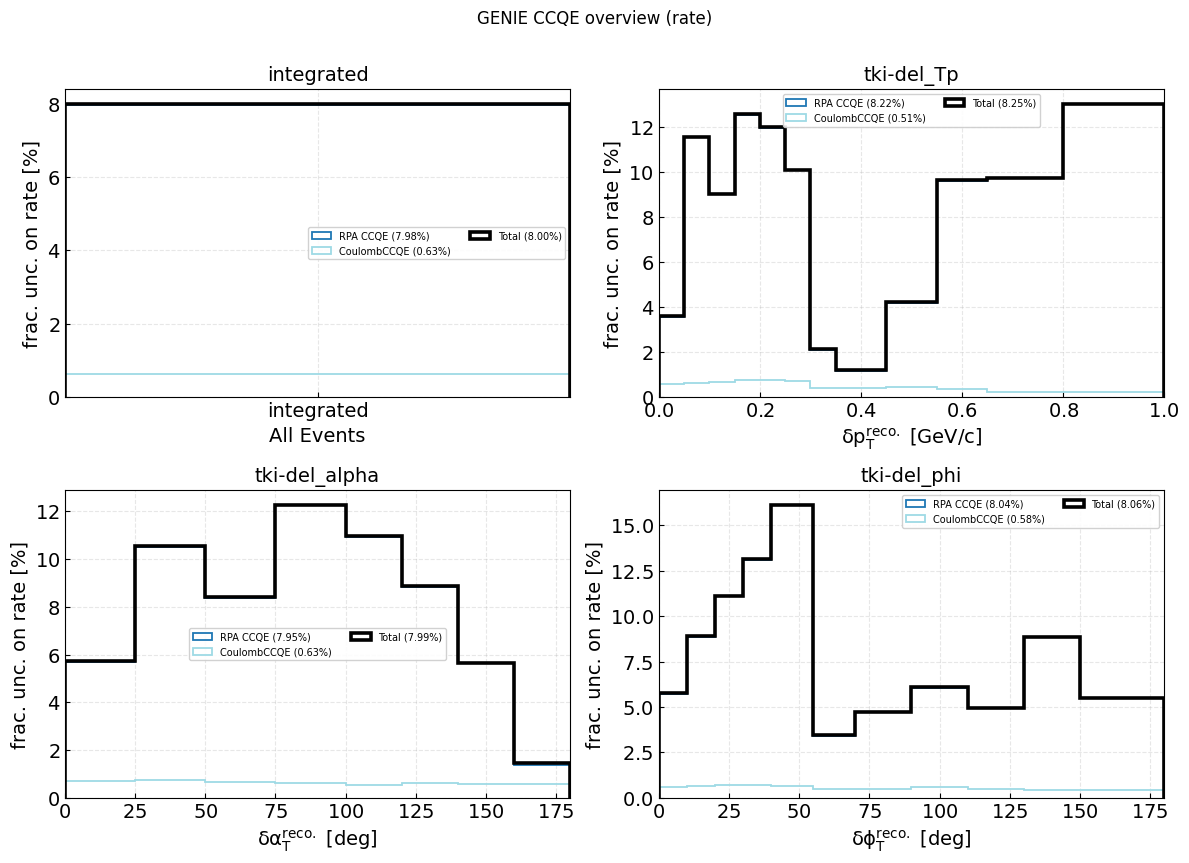

In [19]:
# Per-variable 1x2: xsec | rate (per-knob only; no family grouping for CCQE)
ensure_syst_dicts_for_breakdown()

sn = SYST_TYPES[-1]
out_dir = breakdown_outdir()

_available_vars = []
for vc in var_configs:
    vsn = vc.var_save_name
    if any(
        (sn, vsn) in results_by_cov.get(ct, {}) or vsn in syst_dicts.get(ct, {}).get(sn, {})
        for ct in COV_TYPES
    ):
        _available_vars.append(vc)
    else:
        _log(f'skip breakdown {sn}/{vsn}: missing in all cov_types')

if not _available_vars:
    detail = []
    for ct in COV_TYPES:
        sd = syst_dicts.get(ct, {})
        detail.append(
            f"{ct}: GENIE vars={sorted(sd.get(sn, {}))}, "
            f"results={sorted(v for (s, v) in results_by_cov.get(ct, {}) if s == sn)}"
        )
    raise RuntimeError(
        "No completed variables for breakdown under %r.\n  %s\n"
        "Re-run the covariance loop so syst_dicts[xsec|rate]['GENIE'] is filled."
        % (sn, "\n  ".join(detail))
    )

_log(
    "breakdown using cov_types="
    + ", ".join(
        f"{ct}({len(syst_dicts.get(ct, {}).get(sn, {}))} vars)"
        for ct in COV_TYPES
        if ct in syst_dicts
    )
)

vars_done = []
for vc in _available_vars:
    vsn = vc.var_save_name
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=False)
    any_panel = False
    for icol, ct in enumerate(("xsec", "rate")):
        ax = axes[icol]
        parts, total, per_knob = resolve_breakdown_parts(ct, sn, vsn, group_families=False)
        if total is None and not parts:
            ax.set_visible(False)
            _log(f'skip [{ct}] {sn}/{vsn}: no pack')
            continue
        any_panel = True
        # Prefer explicit per-knob packs when present
        if per_knob:
            parts, total = collect_breakdown_parts(per_knob, group_families=False)
        plot_uncertainty_breakdown(
            ax,
            vc,
            parts,
            total,
            title=f'{ct} — per-knob',
            top_n=BREAKDOWN_TOP_N,
            cov_type_label=ct,
        )

    if not any_panel:
        plt.close(fig)
        continue

    fig.suptitle(
        f'GENIE {GENIE_GROUP} / {sn} / {vsn} — xsec vs rate',
        fontsize=12,
        y=1.02,
    )
    fig.tight_layout()
    if BREAKDOWN_SAVE_FIGS:
        out = out_dir / f'break_xsec_rate__{vsn}.png'
        fig.savefig(out, dpi=BREAKDOWN_FIG_DPI, bbox_inches='tight')
        _log(f'wrote {out}')
    plt.show()
    vars_done.append(vsn)

# Overview: one 2x2 of the four analysis vars, separately for xsec and rate
for ct in COV_TYPES:
    if ct not in syst_dicts and ct not in results_by_cov:
        continue
    fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.5))
    n_drawn = 0
    for ax, vc in zip(axes.ravel(), var_configs):
        vsn = vc.var_save_name
        parts, total, per_knob = resolve_breakdown_parts(ct, sn, vsn, group_families=False)
        if per_knob:
            parts, total = collect_breakdown_parts(per_knob, group_families=False)
        if total is None and not parts:
            ax.set_visible(False)
            continue
        plot_uncertainty_breakdown(
            ax, vc, parts, total, title=vsn, top_n=min(8, BREAKDOWN_TOP_N), cov_type_label=ct
        )
        n_drawn += 1
    if n_drawn == 0:
        plt.close(fig)
        _log(f'skip overview [{ct}]: no variables')
        continue
    fig.suptitle(f'GENIE {GENIE_GROUP} overview ({ct})', fontsize=12, y=1.01)
    fig.tight_layout()
    if BREAKDOWN_SAVE_FIGS:
        out = breakdown_outdir(ct) / f'break_{ct}__overview_2x2.png'
        fig.savefig(out, dpi=BREAKDOWN_FIG_DPI, bbox_inches='tight')
        _log(f'wrote {out}')
    plt.show()

# restore default aliases
cov_type = 'xsec' if 'xsec' in syst_dicts and _syst_dict_nonempty(syst_dicts['xsec']) else (
    next((ct for ct in COV_TYPES if _syst_dict_nonempty(syst_dicts.get(ct, {}))), COV_TYPES[0])
)
syst_dict = syst_dicts.get(cov_type, {})
results_by_syst_var = results_by_cov.get(cov_type, {})
